<div align="center">
<h1  align="center"> ML for Developers</h1>
    Design · Develop · Deploy · Iterate
</div>

<br>
<hr>

This notebooks contains the code for the 🔢&nbsp; Data and 📈&nbsp; Modeling lessons. After this proof of concept (PoC), we'll be moving all of this code to Python scripts to serve our application to production.

# Setup

We'll be using [Ray](https://ray.io) to develop our application using distributed workloads.

In [1]:
# !pip install ray
# !pip install mlflow

In [2]:
import hyperopt
from ray.tune.search.hyperopt import hyperopt_search
hyperopt_search.hpo = hyperopt  # manually inject the working module

from ray.tune.search.hyperopt import HyperOptSearch
from ray.tune.search import ConcurrencyLimiter

initial_params = [{"train_loop_config": {"dropout_p": 0.5, "lr": 1e-4, "lr_factor": 0.8, "lr_patience": 3}}]
search_alg = HyperOptSearch(points_to_evaluate=initial_params)
search_alg = ConcurrencyLimiter(search_alg, max_concurrent=2)
print("✓ Search algorithm ready")

✓ Search algorithm ready


In [3]:
import os
import ray
import sys

In [4]:
# from google.colab import drive
# drive.mount('/content/drive')
# sys.path.append('/content/drive/MyDrive')

In [5]:
import sys; sys.path.append("..")
import warnings; warnings.filterwarnings("ignore")
from dotenv import load_dotenv; load_dotenv()
# %load_ext autoreload
# %autoreload 2

False

In [6]:
# Initialize Ray
if ray.is_initialized():
    ray.shutdown()


import io, sys, os
import ray

if hasattr(sys.stdout, 'buffer'):
    sys.stdout = io.TextIOWrapper(sys.stdout.buffer, encoding='utf-8')
if hasattr(sys.stderr, 'buffer'):
    sys.stderr = io.TextIOWrapper(sys.stderr.buffer, encoding='utf-8')

os.environ["TORCH_DISTRIBUTED_BACKEND"] = "gloo"
os.environ["USE_LIBUV"] = "0"

ray.init(object_store_memory=8 * 1024**3)

# ray.init()

2026-05-02 10:05:02,949	INFO worker.py:2013 -- Started a local Ray instance.


Python version:,3.10.11
Ray version:,2.54.1


(raylet) Stack (most recent call first):
(raylet)   File "D:\mlops\labs\.venv10\lib\site-packages\ray\_private\worker.py", line 625 in job_logging_config
(raylet)   File "D:\mlops\labs\.venv10\lib\site-packages\ray\_private\worker.py", line 2800 in disconnect
(raylet)   File "D:\mlops\labs\.venv10\lib\site-packages\ray\_private\worker.py", line 2132 in shutdown
(raylet)   File "D:\mlops\labs\.venv10\lib\site-packages\ray\_private\worker.py", line 1144 in wrapper


In [7]:
ray.cluster_resources()

{'node:127.0.0.1': 1.0,
 'GPU': 1.0,
 'memory': 8367595520.0,
 'node:__internal_head__': 1.0,
 'accelerator_type:G': 1.0,
 'object_store_memory': 8589934592.0,
 'CPU': 16.0}

These cluster resources only reflect our head node ([m5.2xlarge](https://instances.vantage.sh/aws/ec2/m5.2xlarge)). But recall in our [setup lesson](https://madewithml.com/courses/mlops/setup/) that our [compute configuration](https://madewithml.com/courses/mlops/setup/#compute) that we also added [g4dn.xlarge](https://instances.vantage.sh/aws/ec2/g4dn.xlarge) worker nodes (each has 1 GPU and 4 CPU) to our cluster. But because we set `min_workers=0`, our worker nodes will autoscale ( up to `max_workers`) as they're needed for specific workloads (ex. training).

In [8]:
# Workers (1 g4dn.xlarge)
num_workers = 1
resources_per_worker={"CPU": 14, "GPU": 1}

If you are running this on a local laptop (no GPU), use the CPU count from `ray.cluster_resources()` to set your resources. For example if your machine has 10 CPUs:

```python
num_workers = 6  # prefer to do a few less than total available CPU (1 for head node + 1 for background tasks)
resources_per_worker={"CPU": 1, "GPU": 0}
```

In [9]:
# Storage
EFS_DIR = f"D:\mlops\labs\storage"
print (EFS_DIR)

storage_path = os.path.abspath(EFS_DIR)
print (storage_path)



D:\mlops\labs\storage
D:\mlops\labs\storage


# Data

## Data ingestion

In [10]:
import pandas as pd

In [11]:
# Data ingestion
DATASET_LOC = "https://raw.githubusercontent.com/GokuMohandas/Made-With-ML/main/datasets/dataset.csv"
df = pd.read_csv(DATASET_LOC)
df.head()

,id,created_on,title,description,tag
0,6,2020-02-20 06:43:18,Comparison between YOLO and RCNN on real world...,Bringing theory to experiment is cool. We can ...,computer-vision
1,7,2020-02-20 06:47:21,"Show, Infer & Tell: Contextual Inference for C...",The beauty of the work lies in the way it arch...,computer-vision
2,9,2020-02-24 16:24:45,Awesome Graph Classification,"A collection of important graph embedding, cla...",other
3,15,2020-02-28 23:55:26,Awesome Monte Carlo Tree Search,A curated list of Monte Carlo tree search pape...,other
4,25,2020-03-07 23:04:31,AttentionWalk,"A PyTorch Implementation of ""Watch Your Step: ...",other


In [12]:
df= df.sample(n=100, random_state=42)

## Data splitting

In [13]:
from sklearn.model_selection import train_test_split

In [14]:
# Value counts
df.tag.value_counts()

tag
computer-vision                43
natural-language-processing    37
other                          15
mlops                           5
Name: count, dtype: int64

In [15]:
# Split dataset
test_size = 0.2
train_df, val_df = train_test_split(df, stratify=df.tag, test_size=test_size, random_state=1234)

In [16]:
# Train value counts
train_df.tag.value_counts()

tag
computer-vision                34
natural-language-processing    30
other                          12
mlops                           4
Name: count, dtype: int64

In [17]:
# Validation (adjusted) value counts
val_df.tag.value_counts() * int((1-test_size) / test_size)

tag
computer-vision                36
natural-language-processing    28
other                          12
mlops                           4
Name: count, dtype: int64

## Exploratory Data Analysis (EDA)

Exploratory data analysis to understand the signals and nuances of our dataset. It's a cyclical process that can be done at various points of our development process (before/after labeling, preprocessing, etc.) depending on how well the problem is defined.

In [18]:
# import subprocess
# subprocess.run(["pip", "install", "numpy<2", "--force-reinstall", "-q"])
# subprocess.run(["pip", "install", "matplotlib", "seaborn", "--force-reinstall", "-q"])
# print("Done! Now restart the kernel: Kernel → Restart")

In [19]:
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns; sns.set_theme()
import warnings; warnings.filterwarnings("ignore")
from wordcloud import WordCloud, STOPWORDS

In [20]:
# Most common tags
all_tags = Counter(df.tag)
all_tags.most_common()

[('computer-vision', 43),
 ('natural-language-processing', 37),
 ('other', 15),
 ('mlops', 5)]

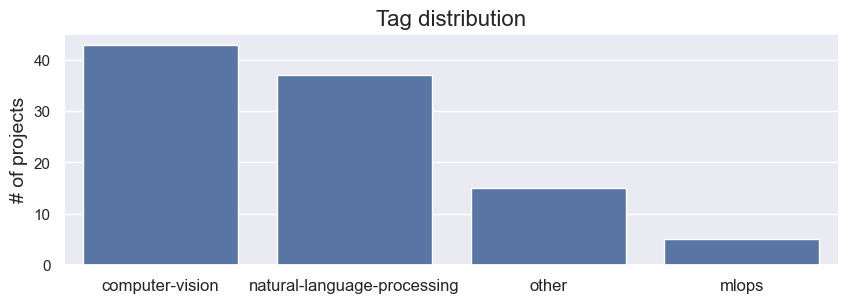

In [21]:
# Plot tag frequencies
tags, tag_counts = zip(*all_tags.most_common())
plt.figure(figsize=(10, 3))
ax = sns.barplot(x=list(tags), y=list(tag_counts))
ax.set_xticklabels(tags, rotation=0, fontsize=12)
plt.title("Tag distribution", fontsize=16)
plt.ylabel("# of projects", fontsize=14)
plt.show()

> We'll address the [data imbalance](https://madewithml.com/courses/mlops/baselines#data-imbalance) after splitting into our train split and prior to training our model.

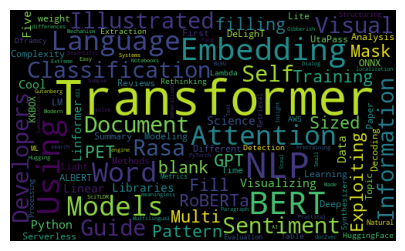

In [22]:
# Most frequent tokens for each tag
tag="natural-language-processing"
plt.figure(figsize=(10, 3))
subset = df[df.tag==tag]
text = subset.title.values
cloud = WordCloud(
    stopwords=STOPWORDS, background_color="black", collocations=False,
    width=500, height=300).generate(" ".join(text))
plt.axis("off")
plt.imshow(cloud)

Looks like the `title` text feature has some good signal for the respective classes and matches our intuition. We can repeat this for the `description` text feature as well. This information will become useful when we decide how to use our features for modeling.

## Data Preprocessing

Preprocessing the data via feature engineering, filtering and cleaning. Certain preprocessing steps are global (don't depend on our dataset, ex. lower casing text, removing stop words, etc.) and others are local (constructs are learned only from the training split, ex. vocabulary, standardization, etc.). For the local, dataset-dependent preprocessing steps, we want to ensure that we [split](https://madewithml.com/courses/mlops/splitting) the data first before preprocessing to avoid data leaks.

In [23]:
import json
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
import re

### Feature engineering

We can combine existing input features to create new meaningful signal (helping the model learn).

In [24]:
# Feature engineering
df["text"] = df.title + " " + df.description

### Clean text

In [25]:
nltk.download("stopwords")
STOPWORDS = stopwords.words("english")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\badrh\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [26]:
def clean_text(text, stopwords=STOPWORDS):
    """Clean raw text string."""
    # Lower
    text = text.lower()

    # Remove stopwords
    pattern = re.compile(r'\b(' + r"|".join(stopwords) + r")\b\s*")
    text = pattern.sub('', text)

    # Spacing and filters
    text = re.sub(r"([!\"'#$%&()*\+,-./:;<=>?@\\\[\]^_`{|}~])", r" \1 ", text)  # add spacing
    text = re.sub("[^A-Za-z0-9]+", " ", text)  # remove non alphanumeric chars
    text = re.sub(" +", " ", text)  # remove multiple spaces
    text = text.strip()  # strip white space at the ends
    text = re.sub(r"http\S+", "", text)  #  remove links

    return text

In [27]:
# Apply to dataframe
original_df = df.copy()
df.text = df.text.apply(clean_text)
print (f"{original_df.text.values[0]}\n{df.text.values[0]}")

Sized Fill-in-the-blank or Multi Mask filling with RoBERTa Sized fill-in-the-blank or conditional text filling is the idea of filling missing words of a sentence with the most probable choice of words.
sized fill blank multi mask filling roberta sized fill blank conditional text filling idea filling missing words sentence probable choice words


### Clean DataFrame

In [28]:
# DataFrame cleanup
df = df.drop(columns=["id", "created_on", "title", "description"], errors="ignore")  # drop cols
df = df.dropna(subset=["tag"])  # drop nulls
df = df[["text", "tag"]]  # rearrange cols
df.head()

,text,tag
357,sized fill blank multi mask filling roberta si...,natural-language-processing
259,s2igan speech image generation via adversarial...,computer-vision
750,make sense reinforcement learning agents log t...,other
193,adversarial latent autoencoders introducing ad...,computer-vision
333,illustrated guide transformers component compo...,natural-language-processing


### Label encoding

We need to encode our data into numerical values so that our models can process them. We'll start by encoding our text labels into unique indices.

In [29]:
# Label to index
tags = train_df.tag.unique().tolist()
num_classes = len(tags)
class_to_index = {tag: i for i, tag in enumerate(tags)}
class_to_index

{'other': 0,
 'computer-vision': 1,
 'natural-language-processing': 2,
 'mlops': 3}

In [30]:
# Encode labels
df["tag"] = df["tag"].map(class_to_index)
df.head()

,text,tag
357,sized fill blank multi mask filling roberta si...,2
259,s2igan speech image generation via adversarial...,1
750,make sense reinforcement learning agents log t...,0
193,adversarial latent autoencoders introducing ad...,1
333,illustrated guide transformers component compo...,2


In [31]:
def decode(indices, index_to_class):
    return [index_to_class[index] for index in indices]

In [32]:
index_to_class = {v:k for k, v in class_to_index.items()}
decode(df.head()["tag"].values, index_to_class=index_to_class)

['natural-language-processing',
 'computer-vision',
 'other',
 'computer-vision',
 'natural-language-processing']

### Tokenizer

Next we'll encode our text as well. Instead of using a random dictionary, we'll use a [tokenizer](https://huggingface.co/allenai/scibert_scivocab_uncased/blob/main/vocab.txt) that was used for a pretrained LLM ([scibert](https://huggingface.co/allenai/scibert_scivocab_uncased)) to tokenize our text. We'll be fine-tuning this exact model later when we train our model.

In [33]:
import numpy as np
from transformers import BertTokenizer

In [34]:
# Bert tokenizer
tokenizer = BertTokenizer.from_pretrained("allenai/scibert_scivocab_uncased", return_dict=False)
text = "Transfer learning with transformers for text classification."
encoded_inputs = tokenizer([text], return_tensors="np", padding="longest")  # pad to longest item in batch
print ("input_ids:", encoded_inputs["input_ids"])
print ("attention_mask:", encoded_inputs["attention_mask"])
print (tokenizer.decode(encoded_inputs["input_ids"][0]))

input_ids: [[  102  2268  1904   190 29155   168  3267  2998   205   103]]
attention_mask: [[1 1 1 1 1 1 1 1 1 1]]
[CLS] transfer learning with transformers for text classification. [SEP]


In [35]:
def tokenize(batch):
    tokenizer = BertTokenizer.from_pretrained("allenai/scibert_scivocab_uncased", return_dict=False)
    encoded_inputs = tokenizer(batch["text"].tolist(), return_tensors="np", padding="longest")
    return dict(ids=encoded_inputs["input_ids"], masks=encoded_inputs["attention_mask"], targets=np.array(batch["tag"]))

In [36]:
# Tokenization
tokenize(df.head(1))

{'ids': array([[  102, 18487,  5104, 13658,   869, 11660, 12852, 12023, 30110,
         18487,  5104, 13658,  7071,  3267, 12852,  4337, 12852,  6252,
          2880,  8517, 12624,  3327,  2880,   103]]),
 'masks': array([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1]]),
 'targets': array([2])}

<hr>

We'll combine all of our preprocessing steps into function:

In [37]:
def preprocess(df, class_to_index):
    """Preprocess the data."""
    df["text"] = df.title + " " + df.description  # feature engineering
    df["text"] = df.text.apply(clean_text)  # clean text
    df = df.drop(columns=["id", "created_on", "title", "description"], errors="ignore")  # clean dataframe
    df = df[["text", "tag"]]  # rearrange columns
    df["tag"] = df["tag"].map(class_to_index)  # label encoding
    outputs = tokenize(df)
    return outputs

In [38]:
# Apply
preprocess(df=train_df, class_to_index=class_to_index)

{'ids': array([[  102, 13534, 14440, ...,     0,     0,     0],
        [  102,  3540, 15519, ...,     0,     0,     0],
        [  102,  1968, 13749, ...,     0,     0,     0],
        ...,
        [  102,  1845,  3687, ...,     0,     0,     0],
        [  102, 20439,  4681, ...,     0,     0,     0],
        [  102,  3787,  1572, ...,     0,     0,     0]], shape=(80, 31)),
 'masks': array([[1, 1, 1, ..., 0, 0, 0],
        [1, 1, 1, ..., 0, 0, 0],
        [1, 1, 1, ..., 0, 0, 0],
        ...,
        [1, 1, 1, ..., 0, 0, 0],
        [1, 1, 1, ..., 0, 0, 0],
        [1, 1, 1, ..., 0, 0, 0]], shape=(80, 31)),
 'targets': array([0, 1, 1, 2, 1, 2, 3, 2, 1, 1, 1, 2, 1, 2, 1, 0, 2, 0, 1, 2, 1, 2,
        1, 2, 2, 2, 1, 2, 2, 2, 1, 1, 2, 0, 1, 1, 0, 1, 3, 2, 1, 2, 2, 0,
        2, 3, 3, 2, 0, 2, 2, 2, 1, 1, 2, 1, 0, 0, 1, 2, 2, 1, 1, 2, 1, 0,
        1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 0, 0, 1, 1])}

### Distributed preprocessing

The main issue with our approach above is that we're limited by our single machine in terms how much data our dataframe can hold and that we can preprocess. With the increasing trend in ML for larger unstructured datasets and larger models (LLMs), we can quickly outgrow our single machine constraints and will need to go distributed.

In [39]:
# from google.colab import files
# files.upload()

In [40]:
from madewithml.data import stratify_split
ray.data.DatasetContext.get_current().execution_options.preserve_order = True

In [41]:
# Data ingestion
ds = ray.data.read_csv(DATASET_LOC)
ds = ds.random_shuffle(seed=1234)
ds.take(1)

2026-05-02 10:05:56,530	INFO dataset.py:3670 -- Tip: Use `take_batch()` instead of `take() / show()` to return records in pandas or numpy batch format.
2026-05-02 10:05:56,677	INFO logging.py:392 -- Registered dataset logger for dataset dataset_2_0
2026-05-02 10:05:56,850	INFO streaming_executor.py:182 -- Starting execution of Dataset dataset_2_0. Full logs are in C:\Users\badrh\AppData\Local\Temp\ray\session_2026-05-02_10-04-48_256216_10648\logs\ray-data
2026-05-02 10:05:56,859	INFO streaming_executor.py:183 -- Execution plan of Dataset dataset_2_0: InputDataBuffer[Input] -> TaskPoolMapOperator[ReadCSV] -> AllToAllOperator[RandomShuffle] -> LimitOperator[limit=1]
2026-05-02 10:05:56,908	INFO __init__.py:56 -- Progress will be logged because stdout is a non-interactive terminal.
2026-05-02 10:05:59,408	INFO logging_progress.py:174 -- ======= Running Dataset: dataset_2_0 =======
2026-05-02 10:05:59,424	INFO logging_progress.py:225 -- Total Progress: 0/?
2026-05-02 10:05:59,424	INFO logg

[{'id': 733,
  'created_on': datetime.datetime(2020, 5, 6, 4, 30, 47),
  'title': 'LandCover.ai',
  'description': 'Dataset for automatic mapping of buildings, woodlands and water from aerial imagery.',
  'tag': 'computer-vision'}]

In [42]:
# Split dataset
test_size = 0.2
train_ds, val_ds = stratify_split(ds, stratify="tag", test_size=test_size)

In [43]:
# Mapping
tags = train_ds.unique(column="tag")
class_to_index = {tag: i for i, tag in enumerate(tags)}

2026-05-02 10:06:21,594	INFO logging.py:392 -- Registered dataset logger for dataset dataset_12_0
2026-05-02 10:06:21,648	INFO hash_shuffle.py:1321 -- Estimated memory requirement for shuffling aggregator (partitions=200, aggregators=16, dataset (estimate)=0.0GiB): shuffle=0.0MiB, output=0.0MiB, total_base=0.0MiB, shuffle_aggregator_memory_estimate_skew_factor=1.3, total_with_skew=0.0MiB
2026-05-02 10:06:21,760	INFO streaming_executor.py:182 -- Starting execution of Dataset dataset_12_0. Full logs are in C:\Users\badrh\AppData\Local\Temp\ray\session_2026-05-02_10-04-48_256216_10648\logs\ray-data
2026-05-02 10:06:21,764	INFO streaming_executor.py:183 -- Execution plan of Dataset dataset_12_0: InputDataBuffer[Input] -> TaskPoolMapOperator[ReadCSV] -> AllToAllOperator[RandomShuffle] -> HashShuffleOperator[Shuffle(key_columns=('tag',), num_partitions=200)] -> AllToAllOperator[MapBatches(_add_split)->MapBatches(_filter_split)->RandomShuffle] -> HashAggregateOperator[HashAggregate(key_column

In [44]:
# Distributed preprocessing
sample_ds = train_ds.map_batches(preprocess, fn_kwargs={"class_to_index": class_to_index}, batch_format="pandas")
sample_ds.show(1)

2026-05-02 10:07:29,682	INFO logging.py:392 -- Registered dataset logger for dataset dataset_20_0
2026-05-02 10:07:29,732	INFO hash_shuffle.py:1321 -- Estimated memory requirement for shuffling aggregator (partitions=200, aggregators=16, dataset (estimate)=0.0GiB): shuffle=0.0MiB, output=0.0MiB, total_base=0.0MiB, shuffle_aggregator_memory_estimate_skew_factor=1.3, total_with_skew=0.0MiB
2026-05-02 10:07:29,765	INFO streaming_executor.py:182 -- Starting execution of Dataset dataset_20_0. Full logs are in C:\Users\badrh\AppData\Local\Temp\ray\session_2026-05-02_10-04-48_256216_10648\logs\ray-data
2026-05-02 10:07:29,780	INFO streaming_executor.py:183 -- Execution plan of Dataset dataset_20_0: InputDataBuffer[Input] -> TaskPoolMapOperator[ReadCSV] -> AllToAllOperator[RandomShuffle] -> HashShuffleOperator[Shuffle(key_columns=('tag',), num_partitions=200)] -> AllToAllOperator[MapBatches(_add_split)->MapBatches(_filter_split)->RandomShuffle] -> TaskPoolMapOperator[MapBatches(preprocess)] ->

{'ids': array([  102, 13783,  5712, 30108,   170,  5712, 30108,   170,  4458,
        7831,  5702,  2112,   255,  2737,   103,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0]), 'masks': array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0]), 'targets': 2}


# Training

When developing models, it's always a best practice to start with the simplest models and slowly motivate more complex models. For example our baseline model progression would be:

1. random model (predict labels randomly)
2. rule-based model (pattern match labels in input text)
3. logistic regression (td-idf vectors from text)
4. CNN (apply character filters over text)
5. Fine-tune LLM (this notebook)

We cover all of these methods in our [other lessons](https://madewithml.com/#foundations) but since our focus here in on MLOps, we will skip directly to fine-tuning an LLM for our task.

We'll first set up some functions that will help us achieve complete reproducibility.

In [45]:
import os
import random
import torch
from ray.data.preprocessor import Preprocessor

In [46]:
def set_seeds(seed=42):
    """Set seeds for reproducibility."""
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    eval("setattr(torch.backends.cudnn, 'deterministic', True)")
    eval("setattr(torch.backends.cudnn, 'benchmark', False)")
    os.environ["PYTHONHASHSEED"] = str(seed)

In [47]:
def load_data(num_samples=None):
    ds = ray.data.read_csv(DATASET_LOC)
    ds = ds.random_shuffle(seed=1234)
    ds = ray.data.from_items(ds.take(num_samples)) if num_samples else ds
    return ds

In [48]:
class CustomPreprocessor():
    """Custom preprocessor class."""
    def __init__(self, class_to_index={}):
        self.class_to_index = class_to_index or {}  # mutable defaults
        self.index_to_class = {v: k for k, v in self.class_to_index.items()}

    def fit(self, ds):
        tags = ds.unique(column="tag")
        self.class_to_index = {tag: i for i, tag in enumerate(tags)}
        self.index_to_class = {v:k for k, v in self.class_to_index.items()}
        return self

    def transform(self, ds):
        return ds.map_batches(
            preprocess,
            fn_kwargs={"class_to_index": self.class_to_index},
            batch_format="pandas")

## Model

In [49]:
import torch.nn as nn
from transformers import BertModel

In [50]:
# Pretrained LLM
llm = BertModel.from_pretrained("allenai/scibert_scivocab_uncased", return_dict=False)
embedding_dim = llm.config.hidden_size

Some weights of the model checkpoint at allenai/scibert_scivocab_uncased were not used when initializing BertModel: ['cls.predictions.transform.LayerNorm.bias', 'cls.seq_relationship.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.decoder.weight', 'cls.seq_relationship.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.decoder.bias', 'cls.predictions.bias', 'cls.predictions.transform.dense.weight']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


In [51]:
# Sample
text = "Transfer learning with transformers for text classification."
# batch = tokenizer([text], return_tensors="np", padding="longest")
# batch = {k:torch.tensor(v) for k,v in batch.items()}  # convert to torch tensors
# seq, pool = llm(input_ids=batch["input_ids"], attention_mask=batch["attention_mask"])
# np.shape(seq), np.shape(pool)
# Fix: return torch tensors directly from tokenizer (skip the numpy step entirely)
batch = tokenizer([text], return_tensors="pt", padding="longest")
seq, pool = llm(input_ids=batch["input_ids"], attention_mask=batch["attention_mask"])
np.shape(seq), np.shape(pool)

(torch.Size([1, 10, 768]), torch.Size([1, 768]))

In [52]:
class FinetunedLLM(nn.Module):
    def __init__(self, llm, dropout_p, embedding_dim, num_classes):
        super(FinetunedLLM, self).__init__()
        self.llm = llm
        self.dropout_p = dropout_p
        self.embedding_dim = embedding_dim
        self.num_classes = num_classes
        self.dropout = torch.nn.Dropout(dropout_p)
        self.fc1 = torch.nn.Linear(embedding_dim, num_classes)

    def forward(self, batch):
        ids, masks = batch["ids"], batch["masks"]
        seq, pool = self.llm(input_ids=ids, attention_mask=masks)
        z = self.dropout(pool)
        z = self.fc1(z)
        return z

    @torch.inference_mode()
    def predict(self, batch):
        self.eval()
        z = self(batch)
        y_pred = torch.argmax(z, dim=1).cpu().numpy()
        return y_pred

    @torch.inference_mode()
    def predict_proba(self, batch):
        self.eval()
        z = self(batch)
        y_probs = F.softmax(z, dim=1).cpu().numpy()
        return y_probs

    def save(self, dp):
        with open(Path(dp, "args.json"), "w") as fp:
            contents = {
                "dropout_p": self.dropout_p,
                "embedding_dim": self.embedding_dim,
                "num_classes": self.num_classes,
            }
            json.dump(contents, fp, indent=4, sort_keys=False)
        torch.save(self.state_dict(), os.path.join(dp, "model.pt"))

    @classmethod
    def load(cls, args_fp, state_dict_fp):
        with open(args_fp, "r") as fp:
            kwargs = json.load(fp=fp)
        llm = BertModel.from_pretrained("allenai/scibert_scivocab_uncased", return_dict=False)
        model = cls(llm=llm, **kwargs)
        model.load_state_dict(torch.load(state_dict_fp, map_location=torch.device("cpu")))
        return model

In [53]:
# Initialize model
model = FinetunedLLM(llm=llm, dropout_p=0.5, embedding_dim=embedding_dim, num_classes=num_classes)
print (model.named_parameters)

<bound method Module.named_parameters of FinetunedLLM(
  (llm): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(31090, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): Layer

## Batching

We can iterate through our dataset in batches however we may have batches of different sizes. Recall that our tokenizer padded the inputs to the longest item in the batch (`padding="longest"`). However, our batches for training will be smaller than our large data processing batches and so our batches here may have inputs with different lengths. To address this, we're going to define a custom `collate_fn` to repad the items in our training batches.

In [54]:
from ray.train.torch import get_device

In [55]:
def pad_array(arr, dtype=np.int32):
    max_len = max(len(row) for row in arr)
    padded_arr = np.zeros((arr.shape[0], max_len), dtype=dtype)
    for i, row in enumerate(arr):
        padded_arr[i][:len(row)] = row
    return padded_arr

In [56]:
def collate_fn(batch):
    batch["ids"] = pad_array(batch["ids"])
    batch["masks"] = pad_array(batch["masks"])
    dtypes = {"ids": torch.int32, "masks": torch.int32, "targets": torch.int64}
    tensor_batch = {}
    for key, array in batch.items():
        # tensor_batch[key] = torch.as_tensor(array, dtype=dtypes[key], device=get_device())
        tensor_batch[key] = torch.as_tensor(array, dtype=dtypes[key])
    return tensor_batch

> `pad=(0, max_len)` in [F.pad](https://pytorch.org/docs/stable/generated/torch.nn.functional.pad.html#torch-nn-functional-pad) refers to (left_padding, right_padding) on the input. There will be no left-padding (hence the `0`) and only right-padding. And the `constant` mode refers to each element being padded to a constant size (size of longest element in the input).

In [57]:
# Sample batch
sample_batch = sample_ds.take_batch(batch_size=128)
collate_fn(batch=sample_batch)

2026-05-02 10:08:45,952	INFO logging.py:392 -- Registered dataset logger for dataset dataset_29_0
2026-05-02 10:08:46,009	INFO hash_shuffle.py:1321 -- Estimated memory requirement for shuffling aggregator (partitions=200, aggregators=16, dataset (estimate)=0.0GiB): shuffle=0.0MiB, output=0.0MiB, total_base=0.0MiB, shuffle_aggregator_memory_estimate_skew_factor=1.3, total_with_skew=0.0MiB
2026-05-02 10:08:46,076	INFO streaming_executor.py:182 -- Starting execution of Dataset dataset_29_0. Full logs are in C:\Users\badrh\AppData\Local\Temp\ray\session_2026-05-02_10-04-48_256216_10648\logs\ray-data
2026-05-02 10:08:46,080	INFO streaming_executor.py:183 -- Execution plan of Dataset dataset_29_0: InputDataBuffer[Input] -> TaskPoolMapOperator[ReadCSV] -> AllToAllOperator[RandomShuffle] -> HashShuffleOperator[Shuffle(key_columns=('tag',), num_partitions=200)] -> AllToAllOperator[MapBatches(_add_split)->MapBatches(_filter_split)->RandomShuffle] -> TaskPoolMapOperator[MapBatches(preprocess)] ->

{'ids': tensor([[  102,  5702,  2112,  ...,     0,     0,     0],
         [  102,  7908,  1968,  ...,     0,     0,     0],
         [  102,  5577,   166,  ...,     0,     0,     0],
         ...,
         [  102,  1623,   849,  ...,     0,     0,     0],
         [  102,  5712, 30108,  ...,     0,     0,     0],
         [  102,   537,  5329,  ...,     0,     0,     0]], dtype=torch.int32),
 'masks': tensor([[1, 1, 1,  ..., 0, 0, 0],
         [1, 1, 1,  ..., 0, 0, 0],
         [1, 1, 1,  ..., 0, 0, 0],
         ...,
         [1, 1, 1,  ..., 0, 0, 0],
         [1, 1, 1,  ..., 0, 0, 0],
         [1, 1, 1,  ..., 0, 0, 0]], dtype=torch.int32),
 'targets': tensor([0, 2, 2, 2, 2, 2, 2, 2, 2, 3, 0, 1, 1, 1, 2, 2, 3, 1, 2, 2, 2, 2, 1, 1,
         2, 2, 1, 1, 1, 0, 2, 2, 1, 1, 2, 2, 3, 1, 0, 2, 2, 3, 2, 2, 1, 0, 1, 3,
         0, 2, 2, 3, 2, 2, 1, 1, 1, 2, 2, 3, 1, 0, 3, 1, 0, 2, 2, 1, 2, 2, 2, 2,
         1, 1, 2, 2, 1, 2, 2, 3, 1, 1, 0, 2, 2, 1, 1, 1, 2, 2, 2, 2, 1, 1, 0, 3,
         1, 1, 

## Utilities

In [58]:
from pathlib import Path
import ray.train as train
import ray.tune as ray_tune

# FIX: Two different RunConfig classes needed in this Ray version:
#   TrainRunConfig  (ray.train.RunConfig)  → required by TorchTrainer
#   TuneRunConfig   (ray.tune.RunConfig)   → required by Tuner
#   (ray.train.RunConfig has verbose="DEPRECATED" which crashes Tuner)
from ray.train import RunConfig as TrainRunConfig
from ray.tune import RunConfig as TuneRunConfig
from ray.train import Checkpoint, DataConfig, ScalingConfig
from ray.train.v2.api.config import CheckpointConfig          # for TorchTrainer/TrainRunConfig
from ray.air.config import CheckpointConfig as TuneCheckpointConfig  # for Tuner/TuneRunConfig
from ray.train.torch import TorchTrainer
import tempfile
import torch.nn.functional as F
from ray.train import RunConfig  # keep alias so existing cells using RunConfig still work
from torch.nn.parallel.distributed import DistributedDataParallel


In [59]:
def train_step(ds, batch_size, model, num_classes, loss_fn, optimizer):
    """Train step."""
    model.train()
    loss = 0.0
    ds_generator = ds.iter_torch_batches(batch_size=batch_size, collate_fn=collate_fn)
    for i, batch in enumerate(ds_generator):
        optimizer.zero_grad()  # reset gradients
        z = model(batch)  # forward pass
        targets = F.one_hot(batch["targets"], num_classes=num_classes).float()  # one-hot (for loss_fn)
        J = loss_fn(z, targets)  # define loss
        J.backward()  # backward pass
        optimizer.step()  # update weights
        loss += (J.detach().item() - loss) / (i + 1)  # cumulative loss
    return loss

In [60]:
def eval_step(ds, batch_size, model, num_classes, loss_fn):
    """Eval step."""
    model.eval()
    loss = 0.0
    y_trues, y_preds = [], []
    ds_generator = ds.iter_torch_batches(batch_size=batch_size, collate_fn=collate_fn)
    with torch.inference_mode():
        for i, batch in enumerate(ds_generator):
            z = model(batch)
            targets = F.one_hot(batch["targets"], num_classes=num_classes).float()  # one-hot (for loss_fn)
            J = loss_fn(z, targets).item()
            loss += (J - loss) / (i + 1)
            y_trues.extend(batch["targets"].cpu().numpy())
            y_preds.extend(torch.argmax(z, dim=1).cpu().numpy())
    return loss, np.vstack(y_trues), np.vstack(y_preds)

In [61]:
# Training loop
def train_loop_per_worker(config):
    import torch
    import torch.nn as nn
    import numpy as np
    class_to_index = config["class_to_index"]  # access it here
    # Hyperparameters
    dropout_p = config["dropout_p"]
    lr = config["lr"]
    lr_factor = config["lr_factor"]
    lr_patience = config["lr_patience"]
    num_epochs = config["num_epochs"]
    batch_size = config["batch_size"]
    num_classes = config["num_classes"]

    # Get datasets
    set_seeds()
    train_ds = train.get_dataset_shard("train")
    val_ds = train.get_dataset_shard("val")

    # Model
    llm = BertModel.from_pretrained("allenai/scibert_scivocab_uncased", return_dict=False)
    model = FinetunedLLM(llm=llm, dropout_p=dropout_p, embedding_dim=llm.config.hidden_size, num_classes=num_classes)
    model = train.torch.prepare_model(model)

    # Training components
    loss_fn = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=lr_factor, patience=lr_patience)

    # Training
    num_workers = train.get_context().get_world_size()
    batch_size_per_worker = batch_size // num_workers
    for epoch in range(num_epochs):
        # Step
        train_loss = train_step(train_ds, batch_size_per_worker, model, num_classes, loss_fn, optimizer)
        val_loss, _, _ = eval_step(val_ds, batch_size_per_worker, model, num_classes, loss_fn)
        scheduler.step(val_loss)

        # Checkpoint
        with tempfile.TemporaryDirectory() as dp:
            if isinstance(model, DistributedDataParallel):  # cpu
                model.module.save(dp=dp)
            else:
                model.save(dp=dp)
            metrics = dict(epoch=epoch, lr=optimizer.param_groups[0]["lr"], train_loss=train_loss, val_loss=val_loss)
            checkpoint = Checkpoint.from_directory(dp)
            checkpoint.set_metadata({"class_to_index": config["class_to_index"]})
            train.report(metrics, checkpoint=checkpoint)

Our dataset doesn't suffer from horrible class imbalance, but if it did, we could easily account for it through our loss function. There are also other strategies such as [over-sampling](https://imbalanced-learn.org/stable/over_sampling.html) less frequent classes and [under-sampling](https://imbalanced-learn.org/stable/under_sampling.html) popular classes.

```python
# Class weights
batch_counts = []
for batch in train_ds.iter_torch_batches(batch_size=256, collate_fn=collate_fn):
    batch_counts.append(np.bincount(batch["targets"].cpu().numpy()))
counts = [sum(count) for count in zip(*batch_counts)]
class_weights = np.array([1.0/count for i, count in enumerate(counts)])
class_weights_tensor = torch.Tensor(class_weights).to(get_device())

# Training components
loss_fn = nn.BCEWithLogitsLoss(weight=class_weights_tensor)
...
```

## Configurations

In [62]:
from madewithml.config import EFS_DIR

In [63]:
# Train loop config
train_loop_config = {
    "dropout_p": 0.5,
    "lr": 1e-4,
    "lr_factor": 0.8,
    "lr_patience": 3,
    "num_epochs": 10,
    "batch_size": 256,
    "num_classes": num_classes,
}

In [64]:
# Scaling config
scaling_config = ScalingConfig(
    num_workers=num_workers,
    use_gpu=bool(resources_per_worker["GPU"]),
    resources_per_worker=resources_per_worker
)

In [65]:
# Run config
checkpoint_config = CheckpointConfig(num_to_keep=1, checkpoint_score_attribute="val_loss", checkpoint_score_order="min")
# FIX: TorchTrainer requires TrainRunConfig (ray.train.RunConfig)
train_run_config = TrainRunConfig(checkpoint_config=checkpoint_config, storage_path=storage_path)
run_config = train_run_config  # alias so rest of training section keeps working


## Training

In [66]:
# Dataset
ds = load_data()
train_ds, val_ds = stratify_split(ds, stratify="tag", test_size=test_size)

In [67]:
# Preprocess
preprocessor = CustomPreprocessor()
preprocessor =  preprocessor.fit(train_ds)
train_ds = preprocessor.transform(train_ds)
val_ds = preprocessor.transform(val_ds)
train_ds = train_ds.materialize()
val_ds = val_ds.materialize()

2026-05-02 10:10:10,314	INFO logging.py:392 -- Registered dataset logger for dataset dataset_60_0
2026-05-02 10:10:10,356	INFO hash_shuffle.py:1321 -- Estimated memory requirement for shuffling aggregator (partitions=200, aggregators=16, dataset (estimate)=0.0GiB): shuffle=0.0MiB, output=0.0MiB, total_base=0.0MiB, shuffle_aggregator_memory_estimate_skew_factor=1.3, total_with_skew=0.0MiB
2026-05-02 10:10:10,390	INFO streaming_executor.py:182 -- Starting execution of Dataset dataset_60_0. Full logs are in C:\Users\badrh\AppData\Local\Temp\ray\session_2026-05-02_10-04-48_256216_10648\logs\ray-data
2026-05-02 10:10:10,398	INFO streaming_executor.py:183 -- Execution plan of Dataset dataset_60_0: InputDataBuffer[Input] -> TaskPoolMapOperator[ReadCSV] -> AllToAllOperator[RandomShuffle] -> HashShuffleOperator[Shuffle(key_columns=('tag',), num_partitions=200)] -> AllToAllOperator[MapBatches(_add_split)->MapBatches(_filter_split)->RandomShuffle] -> HashAggregateOperator[HashAggregate(key_column

In [68]:
# Dataset config
options = ray.data.ExecutionOptions(preserve_order=True)
dataset_config = DataConfig(
    datasets_to_split=["train"],
    execution_options=options)

In [69]:
from ray.train.torch import TorchConfig

# Trainer
train_loop_config["class_to_index"] = preprocessor.class_to_index

trainer = TorchTrainer(
    train_loop_per_worker=train_loop_per_worker,
    train_loop_config=train_loop_config,
    scaling_config=scaling_config,
    run_config=train_run_config,  # FIX: use TrainRunConfig,
    datasets={"train": train_ds, "val": val_ds},
    dataset_config=dataset_config,
    torch_config=TorchConfig(backend="gloo"),  # ← set it here
    # metadata={"class_to_index": preprocessor.class_to_index}
)

In [70]:
import ray
print(ray.cluster_resources())

{'object_store_memory': 8589934592.0, 'GPU': 1.0, 'memory': 8367595520.0, 'accelerator_type:G': 1.0, 'node:__internal_head__': 1.0, 'node:127.0.0.1': 1.0, 'CPU': 16.0}


In [71]:
%%time
# Train

import os
os.environ["TORCH_DISTRIBUTED_BACKEND"] = "gloo"
results = trainer.fit()

(pid=25980) Running Dataset train_69_0.: 0.00 row [00:00, ? row/s]

(pid=25980) - split(1, equal=True):   0%|          | 0.00/1.00 [00:00<?, ? row/s]

(pid=25980) Running Dataset train_69_1.: 0.00 row [00:00, ? row/s]

(pid=25980) - split(1, equal=True):   0%|          | 0.00/1.00 [00:00<?, ? row/s]

(pid=25980) Running Dataset train_69_2.: 0.00 row [00:00, ? row/s]

...

(pid=25980) Running Dataset train_69_8.: 0.00 row [00:00, ? row/s]

(pid=25980) - split(1, equal=True):   0%|          | 0.00/1.00 [00:00<?, ? row/s]

(pid=25980) Running Dataset train_69_9.: 0.00 row [00:00, ? row/s]

(pid=25980) - split(1, equal=True):   0%|          | 0.00/1.00 [00:00<?, ? row/s]

CPU times: total: 3.8 s
Wall time: 6min 23s


In [72]:
# Metrics per epoch
results.metrics_dataframe

,epoch,lr,train_loss,val_loss
0,9,0.0001,0.100277,0.209493


In [73]:
# Best checkpoints
results.best_checkpoints

[(Checkpoint(filesystem=local, path=D:/mlops/labs/storage/ray_train_run-2026-05-02_10-10-09/checkpoint_2026-05-02_10-19-40.352798),
  {'epoch': 9,
   'lr': 0.0001,
   'train_loss': 0.10027653475602467,
   'val_loss': 0.20949292182922363})]

### Evaluation

In [74]:
from sklearn.metrics import precision_recall_fscore_support

In [75]:
class TorchPredictor:
    def __init__(self, preprocessor, model):
        self.preprocessor = preprocessor
        self.model = model
        self.model.eval()

    def __call__(self, batch):
        results = self.model.predict(collate_fn(batch))
        return {"output": results}

    def predict_proba(self, batch):
        results = self.model.predict_proba(collate_fn(batch))
        return {"output": results}

    def get_preprocessor(self):
        return self.preprocessor

    @classmethod
    def from_checkpoint(cls, checkpoint):
        metadata = checkpoint.get_metadata()
        preprocessor = CustomPreprocessor(class_to_index=metadata["class_to_index"])
        model = FinetunedLLM.load(Path(checkpoint.path, "args.json"), Path(checkpoint.path, "model.pt"))
        return cls(preprocessor=preprocessor, model=model)

In [76]:
# Artifacts
best_checkpoint = results.best_checkpoints[0][0]
predictor = TorchPredictor.from_checkpoint(best_checkpoint)
preprocessor = predictor.get_preprocessor()

Some weights of the model checkpoint at allenai/scibert_scivocab_uncased were not used when initializing BertModel: ['cls.predictions.transform.LayerNorm.bias', 'cls.seq_relationship.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.decoder.weight', 'cls.seq_relationship.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.decoder.bias', 'cls.predictions.bias', 'cls.predictions.transform.dense.weight']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


In [77]:
metadata = results.best_checkpoints[0][0].get_metadata()
print(metadata)

{'class_to_index': {'other': 0, 'natural-language-processing': 1, 'mlops': 2, 'computer-vision': 3}}


In [78]:
# Test (holdout) dataset
HOLDOUT_LOC = "https://raw.githubusercontent.com/GokuMohandas/Made-With-ML/main/datasets/holdout.csv"
test_ds = ray.data.read_csv(HOLDOUT_LOC)
preprocessed_ds = preprocessor.transform(test_ds)
preprocessed_ds.take(1)

2026-05-02 10:20:18,816	INFO logging.py:392 -- Registered dataset logger for dataset dataset_82_0
2026-05-02 10:20:18,869	INFO streaming_executor.py:182 -- Starting execution of Dataset dataset_82_0. Full logs are in C:\Users\badrh\AppData\Local\Temp\ray\session_2026-05-02_10-04-48_256216_10648\logs\ray-data
2026-05-02 10:20:18,869	INFO streaming_executor.py:183 -- Execution plan of Dataset dataset_82_0: InputDataBuffer[Input] -> TaskPoolMapOperator[ReadCSV] -> TaskPoolMapOperator[MapBatches(preprocess)] -> LimitOperator[limit=1]
2026-05-02 10:20:18,972	INFO logging_progress.py:174 -- ======= Running Dataset: dataset_82_0 =======
2026-05-02 10:20:18,984	INFO logging_progress.py:225 -- Total Progress: 0/?
2026-05-02 10:20:18,989	INFO logging_progress.py:227 -- Active & requested resources: 0/16 CPU, 0.0B/4.0GiB object store
2026-05-02 10:20:18,989	INFO logging_progress.py:181 -- 
2026-05-02 10:20:18,989	INFO logging_progress.py:231 -- ReadCSV->SplitBlocks(32): 0/1
2026-05-02 10:20:19,01

[{'ids': array([  102,  4905,  2069,  2470,  2848,  4905, 30132, 22081,   691,
          4324,  7491,  5896,   341,  6136,   934, 30137,   103,     0,
             0,     0]),
  'masks': array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0]),
  'targets': 0}]

In [79]:
# y_true
values = preprocessed_ds.select_columns(cols=["targets"]).take_all()
y_true = np.stack([item["targets"] for item in values])
print (y_true)

2026-05-02 10:20:26,145	INFO logging.py:392 -- Registered dataset logger for dataset dataset_91_0
2026-05-02 10:20:26,468	INFO streaming_executor.py:182 -- Starting execution of Dataset dataset_91_0. Full logs are in C:\Users\badrh\AppData\Local\Temp\ray\session_2026-05-02_10-04-48_256216_10648\logs\ray-data
2026-05-02 10:20:26,485	INFO streaming_executor.py:183 -- Execution plan of Dataset dataset_91_0: InputDataBuffer[Input] -> TaskPoolMapOperator[ReadCSV] -> TaskPoolMapOperator[MapBatches(preprocess)->Project]
2026-05-02 10:20:26,857	INFO logging_progress.py:174 -- ======= Running Dataset: dataset_91_0 =======
2026-05-02 10:20:26,873	INFO logging_progress.py:225 -- Total Progress: 0/?
2026-05-02 10:20:26,882	INFO logging_progress.py:227 -- Active & requested resources: 0/16 CPU, 0.0B/4.0GiB object store
2026-05-02 10:20:26,882	INFO logging_progress.py:181 -- 
2026-05-02 10:20:26,907	INFO logging_progress.py:231 -- ReadCSV->SplitBlocks(32): 0/1
2026-05-02 10:20:26,923	INFO logging_pr

[0 0 0 3 1 3 3 3 3 1 3 3 1 0 3 3 1 1 0 1 0 3 0 1 3 1 1 2 2 1 1 1 1 1 1 3 3
 3 3 3 2 2 1 3 3 0 2 1 3 1 1 0 0 3 1 0 1 0 0 0 0 3 3 3 3 1 1 3 1 2 3 1 0 3
 3 1 1 1 1 1 3 3 1 3 2 3 3 3 3 0 3 3 1 3 1 1 0 1 3 1 3 1 3 0 3 3 3 3 3 1 3
 3 1 1 1 1 0 3 1 3 1 3 1 0 0 0 1 3 1 1 1 1 3 1 1 1 3 2 1 1 1 1 1 2 1 3 0 3
 1 1 2 2 1 3 3 3 3 3 3 1 1 1 3 1 2 2 1 3 3 2 1 0 1 1 1 3 3 1 3 1 3 0 3 1 1
 3 2 1 2 1 1]


--- Logging error ---
Traceback (most recent call last):
  File "D:\mlops\labs\.venv10\lib\site-packages\ray\data\_internal\execution\streaming_executor.py", line 904, in get_next
    bundle = state.get_output_blocking(output_split_idx)
  File "D:\mlops\labs\.venv10\lib\site-packages\ray\data\_internal\execution\streaming_executor_state.py", line 328, in get_output_blocking
    raise StopIteration()
StopIteration

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "C:\Users\badrh\AppData\Local\Programs\Python\Python310\lib\logging\__init__.py", line 1103, in emit
    stream.write(msg + self.terminator)
  File "C:\Users\badrh\AppData\Local\Programs\Python\Python310\lib\encodings\cp1252.py", line 19, in encode
    return codecs.charmap_encode(input,self.errors,encoding_table)[0]
UnicodeEncodeError: 'charmap' codec can't encode characters in position 58-59: character maps to <undefined>
Call stack:
  File "C:\Users\badrh\AppData\

In [81]:
# y_pred
predictions = preprocessed_ds.map_batches(predictor).take_all()
y_pred = np.array([d["output"] for d in predictions])

2026-05-02 11:29:28,765	INFO logging.py:392 -- Registered dataset logger for dataset dataset_101_0
2026-05-02 11:29:28,794	INFO streaming_executor.py:182 -- Starting execution of Dataset dataset_101_0. Full logs are in C:\Users\badrh\AppData\Local\Temp\ray\session_2026-05-02_10-04-48_256216_10648\logs\ray-data
2026-05-02 11:29:28,794	INFO streaming_executor.py:183 -- Execution plan of Dataset dataset_101_0: InputDataBuffer[Input] -> TaskPoolMapOperator[ReadCSV] -> TaskPoolMapOperator[MapBatches(preprocess)->MapBatches(TorchPredictor)]
2026-05-02 11:29:28,843	INFO logging_progress.py:174 -- ======= Running Dataset: dataset_101_0 =======
2026-05-02 11:29:28,847	INFO logging_progress.py:225 -- Total Progress: 0/?
2026-05-02 11:29:28,847	INFO logging_progress.py:227 -- Active & requested resources: 0/16 CPU, 0.0B/4.0GiB object store
2026-05-02 11:29:28,849	INFO logging_progress.py:181 -- 
2026-05-02 11:29:28,849	INFO logging_progress.py:231 -- ReadCSV->SplitBlocks(32): 0/1
2026-05-02 11:29

In [82]:
# Evaluate
metrics = precision_recall_fscore_support(y_true, y_pred, average="weighted")
{"precision": metrics[0], "recall": metrics[1], "f1": metrics[2]}

{'precision': 0.8942206312034401,
 'recall': 0.8848167539267016,
 'f1': 0.8882072898967615}

In [83]:
def evaluate(ds, predictor):
    # y_true
    preprocessor = predictor.get_preprocessor()
    preprocessed_ds = preprocessor.transform(ds)
    values = preprocessed_ds.select_columns(cols=["targets"]).take_all()
    y_true = np.stack([item["targets"] for item in values])

    # y_pred
    predictions = preprocessed_ds.map_batches(predictor).take_all()
    y_pred = np.array([d["output"] for d in predictions])

    # Evaluate
    metrics = precision_recall_fscore_support(y_true, y_pred, average="weighted")
    performance = {"precision": metrics[0], "recall": metrics[1], "f1": metrics[2]}
    return performance

In [84]:
# Evaluate on test split
performance = evaluate(ds=test_ds, predictor=predictor)
print (json.dumps(performance, indent=2))

2026-05-02 11:30:00,522	INFO logging.py:392 -- Registered dataset logger for dataset dataset_115_0
2026-05-02 11:30:00,551	INFO streaming_executor.py:182 -- Starting execution of Dataset dataset_115_0. Full logs are in C:\Users\badrh\AppData\Local\Temp\ray\session_2026-05-02_10-04-48_256216_10648\logs\ray-data
2026-05-02 11:30:00,551	INFO streaming_executor.py:183 -- Execution plan of Dataset dataset_115_0: InputDataBuffer[Input] -> TaskPoolMapOperator[ReadCSV] -> TaskPoolMapOperator[MapBatches(preprocess)->Project]
2026-05-02 11:30:00,595	INFO logging_progress.py:174 -- ======= Running Dataset: dataset_115_0 =======
2026-05-02 11:30:00,599	INFO logging_progress.py:225 -- Total Progress: 0/?
2026-05-02 11:30:00,601	INFO logging_progress.py:227 -- Active & requested resources: 0/16 CPU, 0.0B/4.0GiB object store
2026-05-02 11:30:00,603	INFO logging_progress.py:181 -- 
2026-05-02 11:30:00,604	INFO logging_progress.py:231 -- ReadCSV->SplitBlocks(32): 0/1
2026-05-02 11:30:00,605	INFO loggin

{
  "precision": 0.8942206312034401,
  "recall": 0.8848167539267016,
  "f1": 0.8882072898967615
}


--- Logging error ---
Traceback (most recent call last):
  File "D:\mlops\labs\.venv10\lib\site-packages\ray\data\_internal\execution\streaming_executor.py", line 904, in get_next
    bundle = state.get_output_blocking(output_split_idx)
  File "D:\mlops\labs\.venv10\lib\site-packages\ray\data\_internal\execution\streaming_executor_state.py", line 328, in get_output_blocking
    raise StopIteration()
StopIteration

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "C:\Users\badrh\AppData\Local\Programs\Python\Python310\lib\logging\__init__.py", line 1103, in emit
    stream.write(msg + self.terminator)
  File "C:\Users\badrh\AppData\Local\Programs\Python\Python310\lib\encodings\cp1252.py", line 19, in encode
    return codecs.charmap_encode(input,self.errors,encoding_table)[0]
UnicodeEncodeError: 'charmap' codec can't encode characters in position 58-59: character maps to <undefined>
Call stack:
  File "C:\Users\badrh\AppData\

*italicized text*### Inference

In [85]:
import pandas as pd

In [86]:
def format_prob(prob, index_to_class):
    d = {}
    for i, item in enumerate(prob):
        d[index_to_class[i]] = item
    return d

In [87]:
def predict_proba(ds, predictor):
    preprocessor = predictor.get_preprocessor()
    preprocessed_ds = preprocessor.transform(ds)
    outputs = preprocessed_ds.map_batches(predictor.predict_proba)
    y_prob = np.array([d["output"] for d in outputs.take_all()])
    results = []
    for i, prob in enumerate(y_prob):
        tag = preprocessor.index_to_class[prob.argmax()]
        results.append({"prediction": tag, "probabilities": format_prob(prob, preprocessor.index_to_class)})
    return results

In [88]:
# Predict on sample
title = "Transfer learning with transformers"
description = "Using transformers for transfer learning on text classification tasks."
sample_ds = ray.data.from_items([{"title": title, "description": description, "tag": "other"}])
predict_proba(ds=sample_ds, predictor=predictor)

2026-05-02 11:30:33,432	INFO logging.py:392 -- Registered dataset logger for dataset dataset_135_0
2026-05-02 11:30:33,438	INFO streaming_executor.py:182 -- Starting execution of Dataset dataset_135_0. Full logs are in C:\Users\badrh\AppData\Local\Temp\ray\session_2026-05-02_10-04-48_256216_10648\logs\ray-data
2026-05-02 11:30:33,438	INFO streaming_executor.py:183 -- Execution plan of Dataset dataset_135_0: InputDataBuffer[Input] -> TaskPoolMapOperator[MapBatches(preprocess)->MapBatches(TorchPredictor.predict_proba)]
2026-05-02 11:30:34,932	WARNING map_operator.py:500 -- The UDF of operator MapBatches(preprocess)->MapBatches(TorchPredictor.predict_proba) is too large (size = 419.5MiB). Check if the UDF has accidentally captured large objects. Load the large objects in the __init__ method or pass them as ObjectRefs instead.
2026-05-02 11:30:34,942	INFO logging_progress.py:174 -- ======= Running Dataset: dataset_135_0 =======
2026-05-02 11:30:34,942	INFO logging_progress.py:225 -- Total 

[{'prediction': 'natural-language-processing',
  'probabilities': {'other': np.float32(0.0011647183),
   'natural-language-processing': np.float32(0.99698025),
   'mlops': np.float32(0.0010187067),
   'computer-vision': np.float32(0.00083638204)}}]

# Experiment tracking

So far, we've been training our models but we don't have a way to more deeply track and compare them. We'll achieve this but defining a proper process for experiment tracking which we'll use for all future experiments (including hyperparameter optimization). Experiment tracking is the processing of managing all the different experiments and their components, such as parameters, metrics, models and other artifacts and it enables us to:

- **Organize** all the necessary components of a specific experiment. It's important to have everything in one place and know where it is so you can use them later.
- **Reproduce** past results (easily) using saved experiments.
- **Log** iterative improvements across time, data, ideas, teams, etc.

There are many options for experiment tracking but we're going to use [MLflow](https://mlflow.org/) (100% free and [open-source](https://github.com/mlflow/mlflow)) because it has all the functionality we'll need (and [growing integration support](https://docs.ray.io/en/latest/tune/examples/tune-mlflow.html)). There are also several popular options such as a [Comet ML](https://www.comet.ml/site/) (Used by Google AI, HuggingFace, etc.) and [Weights and Biases](https://www.wandb.com/) (Used by Open AI, Toyota Research, etc.). These are fantastic options if you want a fully managed experiment tracking solution.

In [89]:
import mlflow
from pathlib import Path
# from ray.tune.logger.mlflow import MLflowLoggerCallback
import time

In [90]:
# Config MLflow
MODEL_REGISTRY = Path(f"{EFS_DIR}/mlflow")
Path(MODEL_REGISTRY).mkdir(parents=True, exist_ok=True)
MLFLOW_TRACKING_URI = "file://" + str(MODEL_REGISTRY.absolute())
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
print (mlflow.get_tracking_uri())

file://D:\mlops\labs\storage\mlflow


In [91]:
# MLflow callback
experiment_name = f"llm-{int(time.time())}"
# mlflow_callback = MLflowLoggerCallback(
#     tracking_uri=MLFLOW_TRACKING_URI,
#     experiment_name=experiment_name,
#     save_artifact=True)

In [92]:
# Run config (MLflow section)
checkpoint_config = CheckpointConfig(num_to_keep=1, checkpoint_score_attribute="val_loss", checkpoint_score_order="min")
train_run_config = TrainRunConfig(
    checkpoint_config=checkpoint_config,
    storage_path=EFS_DIR,
)
run_config = train_run_config


In [93]:
# Dataset
ds = load_data()
train_ds, val_ds = stratify_split(ds, stratify="tag", test_size=test_size)

In [94]:
# Preprocess
preprocessor = CustomPreprocessor()
preprocessor = preprocessor.fit(train_ds)
train_ds = preprocessor.transform(train_ds)
val_ds = preprocessor.transform(val_ds)
train_ds = train_ds.materialize()
val_ds = val_ds.materialize()

2026-05-02 11:30:59,450	INFO logging.py:392 -- Registered dataset logger for dataset dataset_166_0
2026-05-02 11:30:59,465	INFO hash_shuffle.py:1321 -- Estimated memory requirement for shuffling aggregator (partitions=200, aggregators=16, dataset (estimate)=0.0GiB): shuffle=0.0MiB, output=0.0MiB, total_base=0.0MiB, shuffle_aggregator_memory_estimate_skew_factor=1.3, total_with_skew=0.0MiB
2026-05-02 11:30:59,487	INFO streaming_executor.py:182 -- Starting execution of Dataset dataset_166_0. Full logs are in C:\Users\badrh\AppData\Local\Temp\ray\session_2026-05-02_10-04-48_256216_10648\logs\ray-data
2026-05-02 11:30:59,491	INFO streaming_executor.py:183 -- Execution plan of Dataset dataset_166_0: InputDataBuffer[Input] -> TaskPoolMapOperator[ReadCSV] -> AllToAllOperator[RandomShuffle] -> HashShuffleOperator[Shuffle(key_columns=('tag',), num_partitions=200)] -> AllToAllOperator[MapBatches(_add_split)->MapBatches(_filter_split)->RandomShuffle] -> HashAggregateOperator[HashAggregate(key_col

In [95]:
# Trainer
trainer = TorchTrainer(
    train_loop_per_worker=train_loop_per_worker,
    train_loop_config=train_loop_config,
    scaling_config=scaling_config,
    run_config=train_run_config,  # FIX: use TrainRunConfig,  # uses RunConfig with MLflow callback
    datasets={"train": train_ds, "val": val_ds},
    dataset_config=dataset_config,
    # metadata={"class_to_index": preprocessor.class_to_index}
)

In [ ]:
%%time
# Train
results = trainer.fit()

2026-05-02 15:46:24,968	INFO data_parallel_trainer.py:289 -- Received SIGINT. Gracefully aborting the training run — this may take a few seconds. To forcefully abort immediately, you can send a different signal, such as SIGKILL.


In [231]:
results.metrics_dataframe

,epoch,lr,train_loss,val_loss
0,9,0.0001,0.095778,0.172933


In [232]:
# Best checkpoint from Ray Train results
checkpoints_df = results.metrics_dataframe.sort_values("val_loss")
checkpoints_df
# Best run
best_checkpoint, best_metrics = results.best_checkpoints[0]
print(best_metrics)
# Access metrics directly
best_val_loss = best_metrics["val_loss"]
best_epoch = best_metrics["epoch"]
best_train_loss = best_metrics["train_loss"]

print(f"Best epoch: {best_epoch}")
print(f"Best val_loss: {best_val_loss:.4f}")
print(f"Best train_loss: {best_train_loss:.4f}")

{'epoch': 9, 'lr': 0.0001, 'train_loss': 0.09577848265568416, 'val_loss': 0.1729329526424408}
Best epoch: 9
Best val_loss: 0.1729
Best train_loss: 0.0958


In [233]:
# Load best checkpoint
import torch
# with best_checkpoint.as_directory() as checkpoint_dir:
#     model_state = torch.load(f"{checkpoint_dir}/model.pt")
#     model.load_state_dict(model_state)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

with best_checkpoint.as_directory() as checkpoint_dir:
    model_state = torch.load(
        f"{checkpoint_dir}/model.pt",
        map_location=device
    )
    model.load_state_dict(model_state)
    model.to(device)

In [236]:
# Sorted runs

from pathlib import Path
import mlflow

# Point to wherever your MLflow runs were actually saved
tracking_path = Path(r"D:\mlops\labs\storage")
mlflow.set_tracking_uri(tracking_path.as_uri())  # → file:///D:/mlops/labs/storage

sorted_runs = mlflow.search_runs(
    experiment_names=[experiment_name],
    order_by=["metrics.val_loss ASC"]
)
sorted_runs

Malformed experiment 'mlflow'. Detailed error Yaml file 'D:\mlops\labs\storage\mlflow\meta.yaml' does not exist.
Traceback (most recent call last):
  File "D:\mlops\labs\.venv10\lib\site-packages\mlflow\store\tracking\file_store.py", line 383, in search_experiments
    exp = self._get_experiment(exp_id, view_type)
  File "D:\mlops\labs\.venv10\lib\site-packages\mlflow\store\tracking\file_store.py", line 481, in _get_experiment
    meta = FileStore._read_yaml(experiment_dir, FileStore.META_DATA_FILE_NAME)
  File "D:\mlops\labs\.venv10\lib\site-packages\mlflow\store\tracking\file_store.py", line 1670, in _read_yaml
    return _read_helper(root, file_name, attempts_remaining=retries)
  File "D:\mlops\labs\.venv10\lib\site-packages\mlflow\store\tracking\file_store.py", line 1663, in _read_helper
    result = read_yaml(root, file_name)
  File "D:\mlops\labs\.venv10\lib\site-packages\mlflow\utils\yaml_utils.py", line 104, in read_yaml
    raise MissingConfigException(f"Yaml file '{file_path}

2026/05/02 02:39:17 WARNING mlflow.tracking.fluent: Cannot retrieve experiment by name llm-1777684915


,run_id,experiment_id,status,artifact_uri,start_time,end_time


In [100]:
# # Best run
# best_run = sorted_runs.iloc[0]
# best_run

### Dashboard

Let's view what we've tracked from our experiment. MLFlow serves a dashboard for us to view and explore our experiments on a localhost port:

```bash
mlflow server -h 0.0.0.0 -p 8080 --backend-store-uri $EFS_DIR/mlflow
```

MLFlow creates a main dashboard with all your experiments and their respective runs. We can sort runs by clicking on the column headers.

<img src="https://madewithml.com/static/images/mlops/experiment_tracking/dashboard.png" width="1000" alt="mlflow runs">

And within each run, we can view metrics, parameters, artifacts, etc.

<img src="https://madewithml.com/static/images/mlops/experiment_tracking/params.png" width="1000" alt="mlflow params">

And we can even create custom plots to help us visualize our results.

<img src="https://madewithml.com/static/images/mlops/experiment_tracking/plots.png" width="1000" alt="mlflow plots">

### Loading

In [101]:
# mlflow server -h 0.0.0.0 -p 8080 --backend-store-uri $EFS_DIR/mlflow


In [102]:
from ray.train import Result
from urllib.parse import urlparse

In [103]:
# def get_best_checkpoint(run_id):
#     artifact_dir = urlparse(mlflow.get_run(run_id).info.artifact_uri).path  # get path from mlflow
#     results = Result.from_path(artifact_dir)
#     return results.best_checkpoints[0][0]

In [104]:
def get_best_checkpoint():
    best_checkpoint, best_metrics = results.best_checkpoints[0]
    print(f"Best checkpoint metrics: {best_metrics}")
    return best_checkpoint

In [105]:
# Artifacts
best_checkpoint = get_best_checkpoint()
predictor = TorchPredictor.from_checkpoint(best_checkpoint)
preprocessor = predictor.get_preprocessor()

Best checkpoint metrics: {'epoch': 9, 'lr': 0.0001, 'train_loss': 0.05100918933749199, 'val_loss': 0.14585812389850616}


Some weights of the model checkpoint at allenai/scibert_scivocab_uncased were not used when initializing BertModel: ['cls.predictions.decoder.bias', 'cls.seq_relationship.weight', 'cls.predictions.transform.dense.weight', 'cls.predictions.bias', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.bias', 'cls.seq_relationship.bias', 'cls.predictions.decoder.weight']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


In [106]:
# # Artifacts
# best_checkpoint = get_best_checkpoint(run_id=best_run.run_id)
# predictor = TorchPredictor.from_checkpoint(best_checkpoint)
# preprocessor = predictor.get_preprocessor()

In [107]:
# Evaluate on test split
performance = evaluate(ds=test_ds, predictor=predictor)
print (json.dumps(performance, indent=2))

2026-05-01 23:52:55,064	INFO logging.py:392 -- Registered dataset logger for dataset dataset_148_0
2026-05-01 23:52:55,123	INFO streaming_executor.py:182 -- Starting execution of Dataset dataset_148_0. Full logs are in C:\Users\badrh\AppData\Local\Temp\ray\session_2026-05-01_23-29-11_475242_13956\logs\ray-data
2026-05-01 23:52:55,131	INFO streaming_executor.py:183 -- Execution plan of Dataset dataset_148_0: InputDataBuffer[Input] -> TaskPoolMapOperator[ReadCSV] -> TaskPoolMapOperator[MapBatches(preprocess)->Project]
2026-05-01 23:52:55,222	INFO logging_progress.py:174 -- ======= Running Dataset: dataset_148_0 =======
2026-05-01 23:52:55,230	INFO logging_progress.py:225 -- Total Progress: 0/?
2026-05-01 23:52:55,239	INFO logging_progress.py:227 -- Active & requested resources: 0/16 CPU, 0.0B/4.0GiB object store
2026-05-01 23:52:55,239	INFO logging_progress.py:181 -- 
2026-05-01 23:52:55,247	INFO logging_progress.py:231 -- ReadCSV->SplitBlocks(32): 0/1
2026-05-01 23:52:55,247	INFO loggin

{
  "precision": 0.9483720405153063,
  "recall": 0.9476439790575916,
  "f1": 0.9475636969869858
}


--- Logging error ---
Traceback (most recent call last):
  File "D:\mlops\labs\.venv10\lib\site-packages\ray\data\_internal\execution\streaming_executor.py", line 904, in get_next
    bundle = state.get_output_blocking(output_split_idx)
  File "D:\mlops\labs\.venv10\lib\site-packages\ray\data\_internal\execution\streaming_executor_state.py", line 328, in get_output_blocking
    raise StopIteration()
StopIteration

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "C:\Users\badrh\AppData\Local\Programs\Python\Python310\lib\logging\__init__.py", line 1103, in emit
    stream.write(msg + self.terminator)
  File "C:\Users\badrh\AppData\Local\Programs\Python\Python310\lib\encodings\cp1252.py", line 19, in encode
    return codecs.charmap_encode(input,self.errors,encoding_table)[0]
UnicodeEncodeError: 'charmap' codec can't encode characters in position 58-59: character maps to <undefined>
Call stack:
  File "C:\Users\badrh\AppData\

In [108]:
# Predict on sample
title = "Transfer learning with transformers"
description = "Using transformers for transfer learning on text classification tasks."
sample_ds = ray.data.from_items([{"title": title, "description": description, "tag": "other"}])
predict_proba(ds=sample_ds, predictor=predictor)

2026-05-01 23:54:10,228	INFO logging.py:392 -- Registered dataset logger for dataset dataset_158_0
2026-05-01 23:54:10,253	INFO streaming_executor.py:182 -- Starting execution of Dataset dataset_158_0. Full logs are in C:\Users\badrh\AppData\Local\Temp\ray\session_2026-05-01_23-29-11_475242_13956\logs\ray-data
2026-05-01 23:54:10,257	INFO streaming_executor.py:183 -- Execution plan of Dataset dataset_158_0: InputDataBuffer[Input] -> TaskPoolMapOperator[MapBatches(preprocess)->MapBatches(TorchPredictor.predict_proba)]
2026-05-01 23:54:12,494	WARNING map_operator.py:500 -- The UDF of operator MapBatches(preprocess)->MapBatches(TorchPredictor.predict_proba) is too large (size = 419.5MiB). Check if the UDF has accidentally captured large objects. Load the large objects in the __init__ method or pass them as ObjectRefs instead.
2026-05-01 23:54:12,528	INFO logging_progress.py:174 -- ======= Running Dataset: dataset_158_0 =======
2026-05-01 23:54:12,528	INFO logging_progress.py:225 -- Total 

[{'prediction': 'natural-language-processing',
  'probabilities': {'other': np.float32(0.00036310888),
   'computer-vision': np.float32(0.00058087416),
   'natural-language-processing': np.float32(0.9986066),
   'mlops': np.float32(0.00044935173)}}]

# Hyperparameter tuning

In [109]:
from ray import tune
from ray.tune import Tuner
from ray.tune.schedulers import AsyncHyperBandScheduler
from ray.tune.search import ConcurrencyLimiter
from ray.tune.search.hyperopt import HyperOptSearch

In [110]:
# Number of trials (small sample)
num_runs = 2

In [111]:
# Set up
import torch
import numpy as np
import random

# Patch missing MPS attribute in older/mismatched PyTorch builds on Windows
if not hasattr(torch._C, '_has_mps'):
    torch._C._has_mps = False

def set_seeds(seed=42):
    import random
    import numpy as np
    import torch
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.backends.cudnn.deterministic = True

set_seeds()

In [112]:
# Dataset
ds = load_data()
train_ds, val_ds = stratify_split(ds, stratify="tag", test_size=test_size)

In [113]:
# Preprocess
preprocessor = CustomPreprocessor()
preprocessor = preprocessor.fit(train_ds)
train_ds = preprocessor.transform(train_ds)
val_ds = preprocessor.transform(val_ds)
train_ds = train_ds.materialize()
val_ds = val_ds.materialize()

2026-05-01 23:54:14,674	INFO logging.py:392 -- Registered dataset logger for dataset dataset_169_0
2026-05-01 23:54:14,682	INFO hash_shuffle.py:1321 -- Estimated memory requirement for shuffling aggregator (partitions=200, aggregators=16, dataset (estimate)=0.0GiB): shuffle=0.0MiB, output=0.0MiB, total_base=0.0MiB, shuffle_aggregator_memory_estimate_skew_factor=1.3, total_with_skew=0.0MiB
2026-05-01 23:54:14,722	INFO streaming_executor.py:182 -- Starting execution of Dataset dataset_169_0. Full logs are in C:\Users\badrh\AppData\Local\Temp\ray\session_2026-05-01_23-29-11_475242_13956\logs\ray-data
2026-05-01 23:54:14,730	INFO streaming_executor.py:183 -- Execution plan of Dataset dataset_169_0: InputDataBuffer[Input] -> TaskPoolMapOperator[ReadCSV] -> AllToAllOperator[RandomShuffle] -> HashShuffleOperator[Shuffle(key_columns=('tag',), num_partitions=200)] -> AllToAllOperator[MapBatches(_add_split)->MapBatches(_filter_split)->RandomShuffle] -> HashAggregateOperator[HashAggregate(key_col

Start the check from here

In [114]:
def train_func(config):
    trainer = TorchTrainer(
        train_loop_per_worker=train_loop_per_worker,
        train_loop_config=config["train_loop_config"],
        scaling_config=scaling_config,
        run_config=train_run_config,  # FIX: TorchTrainer requires TrainRunConfig
        datasets={"train": train_ds, "val": val_ds},
        dataset_config=dataset_config,
    )
    return trainer.fit()  # FIX: return result so Tune can track metrics


In [115]:
checkpoint_config = CheckpointConfig(
    num_to_keep=1,
    checkpoint_score_attribute="val_loss",
    checkpoint_score_order="min"
)

train_run_config = TrainRunConfig(
    checkpoint_config=checkpoint_config,
    storage_path=EFS_DIR
)

def trial_dirname_creator(trial):
    # return f"t_{trial.trial_id[:8]}"
    pass

tune_run_config = TuneRunConfig(
    checkpoint_config=TuneCheckpointConfig(
        num_to_keep=1,
    ),
    # storage_path="D:/mlops/labs/storage/mlflow",
    storage_path="D:/mlops/labs/storage",
)

In [116]:
import setuptools  # must be first
import hyperopt    # should now load cleanly
from ray.tune.search.hyperopt import HyperOptSearch
from ray.tune.search import ConcurrencyLimiter

initial_params = [{"train_loop_config": {"dropout_p": 0.5, "lr": 1e-4, "lr_factor": 0.8, "lr_patience": 3}}]
search_alg = HyperOptSearch(points_to_evaluate=initial_params)
search_alg = ConcurrencyLimiter(search_alg, max_concurrent=2)

In [117]:
# Diagnostic cell
import hyperopt
print("hyperopt version:", hyperopt.__version__)

# Check what Ray sees
from ray.tune.search.hyperopt import hyperopt_search
print("hpo value in ray:", hyperopt_search.hpo)

hyperopt version: 0.2.7
hpo value in ray: <module 'hyperopt' from 'D:\\mlops\\labs\\.venv10\\lib\\site-packages\\hyperopt\\__init__.py'>


In [118]:
# Hyperparameters to start with
initial_params = [{"train_loop_config": {"dropout_p": 0.5, "lr": 1e-4, "lr_factor": 0.8, "lr_patience": 3}}]
search_alg = HyperOptSearch(points_to_evaluate=initial_params)
search_alg = ConcurrencyLimiter(search_alg, max_concurrent=2)  # trade off b/w optimization and search space

In [119]:
# param_space = {
#     "train_loop_config": {
#         "dropout_p": tune.uniform(0.3, 0.9),
#         "lr": tune.loguniform(1e-5, 5e-4),
#         "lr_factor": tune.uniform(0.1, 0.9),
#         "lr_patience": tune.uniform(1, 10),
#     }
# }

param_space = {
    "train_loop_config": {
        "dropout_p": tune.uniform(0.3, 0.9),
        "lr": tune.loguniform(1e-5, 5e-4),
        "lr_factor": tune.uniform(0.1, 0.9),
        "lr_patience": tune.randint(1, 10),  # ← randint not uniform
    }
}

In [120]:
# Scheduler
scheduler = AsyncHyperBandScheduler(
    max_t=train_loop_config["num_epochs"],  # max epoch (<time_attr>) per trial
    grace_period=5,  # min epoch (<time_attr>) per trial
)

In [121]:
# Tune config
tune_config = tune.TuneConfig(
    metric="val_loss",
    mode="min",
    search_alg=search_alg,
    scheduler=scheduler,
    num_samples=num_runs,
    trial_dirname_creator=trial_dirname_creator,
)

I wanto to save all the above code

In [122]:
# ============================================================
# SAVE STATE — run this once after all setup cells complete
# ============================================================
import pickle, os, json
import ray

SAVE_DIR = "D:/mlops/labs/states/notebook_state"
os.makedirs(SAVE_DIR, exist_ok=True)

# 1. Save Ray datasets as parquet
train_ds.write_parquet(f"{SAVE_DIR}/train_ds")
val_ds.write_parquet(f"{SAVE_DIR}/val_ds")

# 2. Save preprocessor and configs with pickle
state = {
    "class_to_index": preprocessor.class_to_index,
    "index_to_class": preprocessor.index_to_class,
    "train_loop_config": train_loop_config,
    "num_workers": num_workers,
    "resources_per_worker": resources_per_worker,
    "num_runs": num_runs,
    "EFS_DIR": EFS_DIR,
    "DATASET_LOC": DATASET_LOC,
}
with open(f"{SAVE_DIR}/state.pkl", "wb") as f:
    pickle.dump(state, f)

print(f"✓ State saved to {SAVE_DIR}")

2026-05-01 23:59:47,927	INFO logging.py:392 -- Registered dataset logger for dataset dataset_183_0
2026-05-01 23:59:47,943	INFO streaming_executor.py:182 -- Starting execution of Dataset dataset_183_0. Full logs are in C:\Users\badrh\AppData\Local\Temp\ray\session_2026-05-01_23-29-11_475242_13956\logs\ray-data
2026-05-01 23:59:47,943	INFO streaming_executor.py:183 -- Execution plan of Dataset dataset_183_0: InputDataBuffer[Input] -> TaskPoolMapOperator[Write]
2026-05-01 23:59:48,092	INFO logging_progress.py:174 -- ======= Running Dataset: dataset_183_0 =======
2026-05-01 23:59:48,103	INFO logging_progress.py:225 -- Total Progress: 0/?
2026-05-01 23:59:48,108	INFO logging_progress.py:227 -- Active & requested resources: 0/16 CPU, 0.0B/4.0GiB object store
2026-05-01 23:59:48,108	INFO logging_progress.py:181 -- 
2026-05-01 23:59:48,113	INFO logging_progress.py:231 -- Write: 0/1
2026-05-01 23:59:48,118	INFO logging_progress.py:233 --   Tasks: 1; Actors: 0; Queued blocks: 199 (0.0B); Resour

✓ State saved to D:/mlops/labs/states/notebook_state


In [123]:
# ============================================================
# LOAD STATE — run this instead of all setup cells
# ============================================================
import pickle, os, ray
import io, sys

os.environ["TORCH_DISTRIBUTED_BACKEND"] = "gloo"
os.environ["USE_LIBUV"] = "0"
os.environ["RAY_TMPDIR"] = "D:/mlops/labs/states"
os.makedirs("D:/mlops/labs/states/ray_tmp", exist_ok=True)

if ray.is_initialized():
    ray.shutdown()
ray.init(object_store_memory=8 * 1024**3)

SAVE_DIR = "D:/mlops/labs/states/notebook_state"

# Load datasets
train_ds = ray.data.read_parquet(f"{SAVE_DIR}/train_ds")
val_ds   = ray.data.read_parquet(f"{SAVE_DIR}/val_ds")

# Load configs
with open(f"{SAVE_DIR}/state.pkl", "rb") as f:
    state = pickle.load(f)

class_to_index       = state["class_to_index"]
index_to_class       = state["index_to_class"]
train_loop_config    = state["train_loop_config"]
num_workers          = state["num_workers"]
resources_per_worker = state["resources_per_worker"]
num_runs             = state["num_runs"]
EFS_DIR              = state["EFS_DIR"]
DATASET_LOC          = state["DATASET_LOC"]

# Rebuild preprocessor from saved class_to_index (no refit needed)
from madewithml.data import CustomPreprocessor  # adjust import if needed
preprocessor = CustomPreprocessor(class_to_index=class_to_index)

print("✓ State loaded — ready to run tuning cells")
print(f"  train_ds: {train_ds.count()} rows")
print(f"  val_ds:   {val_ds.count()} rows")
print(f"  classes:  {class_to_index}")

2026-05-02 00:01:45,620	INFO worker.py:2013 -- Started a local Ray instance.


Parquet dataset sampling:   0%|          | 0.00/2.00 [00:00<?, ? file/s]

2026-05-02 00:02:18,952	INFO parquet_datasource.py:1079 -- Estimated parquet encoding ratio is 0.651.
2026-05-02 00:02:18,959	INFO parquet_datasource.py:1139 -- Estimated parquet reader batch size at 369099 rows


Parquet dataset sampling:   0%|          | 0.00/2.00 [00:00<?, ? file/s]

2026-05-02 00:02:43,159	INFO parquet_datasource.py:1079 -- Estimated parquet encoding ratio is 0.154.
2026-05-02 00:02:43,172	INFO parquet_datasource.py:1139 -- Estimated parquet reader batch size at 475626 rows
2026-05-02 00:02:43,328	INFO logging.py:392 -- Registered dataset logger for dataset dataset_2_0
2026-05-02 00:02:43,456	INFO streaming_executor.py:182 -- Starting execution of Dataset dataset_2_0. Full logs are in D:/mlops/labs/states\ray\session_2026-05-02_00-01-05_472562_13956\logs\ray-data
2026-05-02 00:02:43,464	INFO streaming_executor.py:183 -- Execution plan of Dataset dataset_2_0: InputDataBuffer[Input] -> TaskPoolMapOperator[ReadParquet] -> AggregateNumRows[AggregateNumRows]


...

2026-05-02 00:02:49,751	WARNING default_autoscaling_coordinator.py:134 -- Failed to send resource request for data-dataset_2_0. If this only happens transiently during network partition or CPU being overloaded, it's safe to ignore this error. If this error persists, file a GitHub issue.
Traceback (most recent call last):
  File "D:\mlops\labs\.venv10\lib\site-packages\ray\data\_internal\cluster_autoscaler\default_autoscaling_coordinator.py", line 98, in wrapper
    result = func(self, *args, **kwargs)
  File "D:\mlops\labs\.venv10\lib\site-packages\ray\data\_internal\cluster_autoscaler\default_autoscaling_coordinator.py", line 181, in request_resources
    ray.get(
  File "D:\mlops\labs\.venv10\lib\site-packages\ray\_private\auto_init_hook.py", line 22, in auto_init_wrapper
    return fn(*args, **kwargs)
  File "D:\mlops\labs\.venv10\lib\site-packages\ray\_private\client_mode_hook.py", line 104, in wrapper
    return func(*args, **kwargs)
  File "D:\mlops\labs\.venv10\lib\site-packages

  train_ds: 610 rows


2026-05-02 00:02:59,742	INFO logging_progress.py:231 -- AggregateNumRows: 0/1
2026-05-02 00:02:59,748	INFO logging_progress.py:233 --   Tasks: 0; Actors: 0; Queued blocks: 0 (0.0B); Resources: 0.0 CPU, 0.0B object store
2026-05-02 00:02:59,766	INFO logging_progress.py:192 -- ============================================
--- Logging error ---
Traceback (most recent call last):
  File "D:\mlops\labs\.venv10\lib\site-packages\ray\data\_internal\execution\streaming_executor.py", line 904, in get_next
    bundle = state.get_output_blocking(output_split_idx)
  File "D:\mlops\labs\.venv10\lib\site-packages\ray\data\_internal\execution\streaming_executor_state.py", line 328, in get_output_blocking
    raise StopIteration()
StopIteration

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "C:\Users\badrh\AppData\Local\Programs\Python\Python310\lib\logging\__init__.py", line 1103, in emit
    stream.write(msg + self.terminator)
  File "C

  val_ds:   154 rows
  classes:  {'other': 0, 'natural-language-processing': 1, 'mlops': 2, 'computer-vision': 3}


--- Logging error ---
Traceback (most recent call last):
  File "D:\mlops\labs\.venv10\lib\site-packages\ray\data\_internal\execution\streaming_executor.py", line 904, in get_next
    bundle = state.get_output_blocking(output_split_idx)
  File "D:\mlops\labs\.venv10\lib\site-packages\ray\data\_internal\execution\streaming_executor_state.py", line 328, in get_output_blocking
    raise StopIteration()
StopIteration

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "C:\Users\badrh\AppData\Local\Programs\Python\Python310\lib\logging\__init__.py", line 1103, in emit
    stream.write(msg + self.terminator)
  File "C:\Users\badrh\AppData\Local\Programs\Python\Python310\lib\encodings\cp1252.py", line 19, in encode
    return codecs.charmap_encode(input,self.errors,encoding_table)[0]
UnicodeEncodeError: 'charmap' codec can't encode characters in position 58-59: character maps to <undefined>
Call stack:
  File "C:\Users\badrh\AppData\

In [124]:
# ============================================================
# QUICK TEST MODE — flip IS_TEST=False for full run
# ============================================================
import copy
import hyperopt
from ray.tune.search.hyperopt import hyperopt_search
hyperopt_search.hpo = hyperopt  # manually inject the working module

from ray.tune.search.hyperopt import HyperOptSearch
from ray.tune.search import ConcurrencyLimiter

IS_TEST = True

if IS_TEST:
    # 1. Fewer epochs + larger batch = fewer steps per epoch
    fast_train_loop_config = copy.deepcopy(train_loop_config)
    fast_train_loop_config["num_epochs"] = 2
    fast_train_loop_config["batch_size"] = 64

    # 2. Smaller dataset — only 200 train / 50 val rows
    fast_train_ds = train_ds.limit(200)
    fast_val_ds   = val_ds.limit(50)

    # 3. Fewer trials, less concurrency
    fast_num_runs = 2
    fast_search_alg = ConcurrencyLimiter(
        HyperOptSearch(points_to_evaluate=initial_params),
        max_concurrent=1
    )

    # 4. Scheduler matched to epoch count
    fast_scheduler = AsyncHyperBandScheduler(max_t=2, grace_period=1)

    # 5. Fast tune config
    fast_tune_config = tune.TuneConfig(
        metric="val_loss",
        mode="min",
        search_alg=fast_search_alg,
        scheduler=fast_scheduler,
        num_samples=fast_num_runs,
        trial_dirname_creator=trial_dirname_creator,
    )

    # 6. Swap train_func datasets
    def fast_train_func(config):
        from ray.train.torch import TorchConfig, TorchTrainer
        import ray.tune as tune

        trainer = TorchTrainer(
            train_loop_per_worker=train_loop_per_worker,
            train_loop_config=config["train_loop_config"],
            scaling_config=scaling_config,
            run_config=train_run_config,
            datasets={"train": fast_train_ds, "val": fast_val_ds},
            dataset_config=dataset_config,
            torch_config=TorchConfig(backend="gloo"),
        )
        result = trainer.fit()
        best_checkpoint, best_metrics = result.best_checkpoints[0]
        tune.report({  # ← dict, not kwargs
            "val_loss": best_metrics["val_loss"],
            "train_loss": best_metrics["train_loss"],
            "epoch": best_metrics["epoch"],
        })

    # Override for the Tuner cell below
    _tuner_func   = fast_train_func
    _tuner_space  = {
        "train_loop_config": {
            **fast_train_loop_config,
            "dropout_p": tune.uniform(0.3, 0.9),
            "lr":        tune.loguniform(1e-5, 5e-4),
            "lr_factor": tune.uniform(0.1, 0.9),
            "lr_patience": tune.randint(1, 5),
        }
    }
    _tuner_config = fast_tune_config

else:
    # Full run — use original values
    _tuner_func   = train_func
    _tuner_space  = param_space
    _tuner_config = tune_config

print(f"{' QUICK TEST' if IS_TEST else ' FULL RUN'} mode active")

 QUICK TEST mode active


In [125]:
%%time
tuner = Tuner(
    _tuner_func,
    param_space=_tuner_space,
    tune_config=_tuner_config,
    run_config=tune_run_config,
)
tuning_results = tuner.fit()

(pid=26184) Running Dataset train_6_0.: 0.00 row [00:00, ? row/s]

(pid=26184) - ReadParquet:   0%|          | 0.00/1.00 [00:00<?, ? row/s]

(pid=26184) - limit=200:   0%|          | 0.00/1.00 [00:00<?, ? row/s]

(pid=26184) - split(1, equal=True):   0%|          | 0.00/1.00 [00:00<?, ? row/s]

(pid=21428) Running Dataset val_8_0.: 0.00 row [00:00, ? row/s]

...

(pid=25652) Running Dataset val_11_1.: 0.00 row [00:00, ? row/s]

(pid=25652) - ReadParquet:   0%|          | 0.00/1.00 [00:00<?, ? row/s]

(pid=25652) - limit=50:   0%|          | 0.00/1.00 [00:00<?, ? row/s]

2026-05-02 00:05:17,409	INFO tune.py:1009 -- Wrote the latest version of all result files and experiment state to 'D:/mlops/labs/storage/store/fast_train_func_2026-05-02_00-03-00' in 0.0205s.
2026-05-02 00:05:17,558	INFO tune.py:1041 -- Total run time: 137.09 seconds (135.38 seconds for the tuning loop).


CPU times: total: 3.98 s
Wall time: 2min 17s


In [126]:
# %%time
# # FIX: Tuner must receive TuneRunConfig (ray.tune.RunConfig), not TrainRunConfig
# tuner = Tuner(
#     train_func,2
#     param_space=param_space,
#     tune_config=tune_config,
#     run_config=tune_run_config,
# )
# tuning_results = tuner.fit()


In [127]:
# All trials in experiment
tuning_results.get_dataframe()  # FIX: was results.get_dataframe()


,val_loss,train_loss,epoch,timestamp,checkpoint_dir_name,done,training_iteration,trial_id,date,time_this_iter_s,...,config/train_loop_config/lr_factor,config/train_loop_config/lr_patience,config/train_loop_config/num_epochs,config/train_loop_config/batch_size,config/train_loop_config/num_classes,config/train_loop_config/class_to_index/other,config/train_loop_config/class_to_index/computer-vision,config/train_loop_config/class_to_index/natural-language-processing,config/train_loop_config/class_to_index/mlops,logdir
0,0.501352,0.597703,0,1777676649,None,False,1,cdad2f3b,2026-05-02_00-04-09,54.511927,...,0.800000,3,2,64,4,0,1,2,3,cdad2f3b
1,0.501170,0.643488,0,1777676717,None,False,1,3a421e3b,2026-05-02_00-05-17,46.528440,...,0.717277,1,2,64,4,0,1,2,3,3a421e3b


In [128]:
# Best trial's epochs
best_trial = tuning_results.get_best_result(metric="val_loss", mode="min")  # FIX: was results.get_best_result
best_trial.metrics_dataframe


,val_loss,train_loss,epoch,timestamp,checkpoint_dir_name,done,training_iteration,trial_id,date,time_this_iter_s,...,config/train_loop_config/lr,config/train_loop_config/lr_factor,config/train_loop_config/lr_patience,config/train_loop_config/num_epochs,config/train_loop_config/batch_size,config/train_loop_config/num_classes,config/train_loop_config/class_to_index/other,config/train_loop_config/class_to_index/computer-vision,config/train_loop_config/class_to_index/natural-language-processing,config/train_loop_config/class_to_index/mlops
0,0.50117,0.643488,0,1777676717,None,False,1,3a421e3b,2026-05-02_00-05-17,46.52844,...,0.000311,0.717277,1,2,64,4,0,1,2,3


In [129]:
# Best trial's hyperparameters
best_trial.config["train_loop_config"]

{'dropout_p': 0.836524138243991,
 'lr': 0.0003109200486739789,
 'lr_factor': 0.7172770717584167,
 'lr_patience': 1,
 'num_epochs': 2,
 'batch_size': 64,
 'num_classes': 4,
 'class_to_index': {'other': 0,
  'computer-vision': 1,
  'natural-language-processing': 2,
  'mlops': 3}}

In [130]:
import shutil
from pathlib import Path

mlflow_dir = Path("D:/mlops/labs/storage/mlflow")
for folder in mlflow_dir.iterdir():
    if folder.is_dir() and not (folder / "meta.yaml").exists():
        shutil.rmtree(folder)
        print(f"Removed: {folder.name}")
print("Done")

Done


In [135]:
import mlflow
from pathlib import Path

# ← Point to the SUBFOLDER, not EFS_DIR itself
# MLFLOW_DIR = Path("D:/mlops/labs/storage/mlflow")
MLFLOW_DIR = Path("D:/mlops/labs/storage")
MLFLOW_DIR.mkdir(parents=True, exist_ok=True)

MLFLOW_TRACKING_URI = "file:///" + str(MLFLOW_DIR).replace("\\", "/")
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
print("Tracking URI:", mlflow.get_tracking_uri())

# Fixed experiment name (not timestamp-based)
experiment_name = "llm-tuning"

# Create if doesn't exist
if mlflow.get_experiment_by_name(experiment_name) is None:
    mlflow.create_experiment(experiment_name)

mlflow.set_experiment(experiment_name)
print("Experiment set:", experiment_name)

# Search runs
sorted_runs = mlflow.search_runs(
    experiment_names=[experiment_name],
    order_by=["metrics.val_loss ASC"]
)
print(sorted_runs)

Tracking URI: file:///D:/mlops/labs/storage
Malformed experiment 'mlflow'. Detailed error Yaml file 'D:\mlops\labs\storage\mlflow\meta.yaml' does not exist.
Traceback (most recent call last):
  File "D:\mlops\labs\.venv10\lib\site-packages\mlflow\store\tracking\file_store.py", line 383, in search_experiments
    exp = self._get_experiment(exp_id, view_type)
  File "D:\mlops\labs\.venv10\lib\site-packages\mlflow\store\tracking\file_store.py", line 481, in _get_experiment
    meta = FileStore._read_yaml(experiment_dir, FileStore.META_DATA_FILE_NAME)
  File "D:\mlops\labs\.venv10\lib\site-packages\mlflow\store\tracking\file_store.py", line 1670, in _read_yaml
    return _read_helper(root, file_name, attempts_remaining=retries)
  File "D:\mlops\labs\.venv10\lib\site-packages\mlflow\store\tracking\file_store.py", line 1663, in _read_helper
    result = read_yaml(root, file_name)
  File "D:\mlops\labs\.venv10\lib\site-packages\mlflow\utils\yaml_utils.py", line 104, in read_yaml
    raise Mis

In [132]:
# Sorted runs
sorted_runs = mlflow.search_runs(experiment_names=[experiment_name], order_by=["metrics.val_loss ASC"])
sorted_runs

,run_id,experiment_id,status,artifact_uri,start_time,end_time


In [133]:
# Get best result path and load checkpoint directly
best_result = tuning_results.get_best_result(metric="val_loss", mode="min")
print("Best result path:", best_result.path)

# Load checkpoint directly from the trainer result stored in that path
from ray.train import Result
train_result = Result.from_path(best_result.path)
print("Train result checkpoints:", train_result.best_checkpoints)

best_checkpoint, best_metrics = train_result.best_checkpoints[0]
print("Checkpoint:", best_checkpoint)

predictor = TorchPredictor.from_checkpoint(best_checkpoint)
preprocessor = predictor.get_preprocessor()

Best result path: D:/mlops/labs/storage/store/fast_train_func_2026-05-02_00-03-00/t_3a421e3b


RuntimeError: Failed to restore the Result object: checkpoint_manager_snapshot.json doesn't exist in the experiment folder. Make sure that this is an output directory created by a Ray Train run.

In [134]:
best_result = tuning_results.get_best_result(metric="val_loss", mode="min")
best_checkpoint = best_result.checkpoint
predictor = TorchPredictor.from_checkpoint(best_checkpoint)
preprocessor = predictor.get_preprocessor()

AttributeError: 'NoneType' object has no attribute 'get_metadata'

In [135]:
# Artifacts
# FIX: get_best_checkpoint() takes no args; retrieve checkpoint directly from tuning_results
best_checkpoint = tuning_results.get_best_result(metric="val_loss", mode="min").checkpoint
predictor = TorchPredictor.from_checkpoint(best_checkpoint)
preprocessor = predictor.get_preprocessor()


AttributeError: 'NoneType' object has no attribute 'get_metadata'

In [136]:
# Evaluate on test split
performance = evaluate(ds=test_ds, predictor=predictor)
print (json.dumps(performance, indent=2))

2026-05-01 22:35:58,680	INFO logging.py:392 -- Registered dataset logger for dataset dataset_43_0
2026-05-01 22:35:58,690	ERROR exceptions.py:73 -- Exception occurred in Ray Data or Ray Core internal code. If you continue to see this error, please open an issue on the Ray project GitHub page with the full stack trace below: https://github.com/ray-project/ray/issues/new/choose
2026-05-01 22:35:58,696	ERROR exceptions.py:81 -- Full stack trace:
Traceback (most recent call last):
  File "D:\mlops\labs\.venv10\lib\site-packages\ray\data\exceptions.py", line 49, in handle_trace
    return fn(*args, **kwargs)
  File "D:\mlops\labs\.venv10\lib\site-packages\ray\data\_internal\plan.py", line 474, in execute_to_iterator
    bundle_iter = execute_to_legacy_bundle_iterator(executor, self)
  File "D:\mlops\labs\.venv10\lib\site-packages\ray\data\_internal\execution\legacy_compat.py", line 44, in execute_to_legacy_bundle_iterator
    dag, stats = _get_execution_dag(
  File "D:\mlops\labs\.venv10\li

ValueError: You are trying to access Ray objects whose owner is unknown. Please make sure that all Ray objects you are trying to access are part of the current Ray session. Note that object IDs generated randomly (ObjectID.from_random()) or out-of-band (ObjectID.from_binary(...)) cannot be passed as a task argument because Ray does not know which task created them. If this was not how your object ID was generated, please file an issue at https://github.com/ray-project/ray/issues/. Owners not found for objects [00ffffffffffffffffffffffffffffffffffffff010000001ae1f505, ].

In [137]:
# Predict on sample
title = "Transfer learning with transformers"
description = "Using transformers for transfer learning on text classification tasks."
sample_ds = ray.data.from_items([{"title": title, "description": description, "tag": "other"}])
predict_proba(ds=sample_ds, predictor=predictor)

2026-05-01 22:36:04,928	INFO logging.py:392 -- Registered dataset logger for dataset dataset_49_0
2026-05-01 22:36:04,928	INFO logging.py:400 -- dataset_49_0 registers for logging while another dataset dataset_43_0 is also logging. For performance reasons, we will not log to the dataset dataset_49_0 until it is the only active dataset.
2026-05-01 22:36:04,928	INFO streaming_executor.py:182 -- Starting execution of Dataset dataset_49_0. Full logs are in D:/mlops/labs/states\ray\session_2026-05-01_18-03-34_189575_22364\logs\ray-data
2026-05-01 22:36:04,936	INFO streaming_executor.py:183 -- Execution plan of Dataset dataset_49_0: InputDataBuffer[Input] -> TaskPoolMapOperator[MapBatches(preprocess)->MapBatches(TorchPredictor.predict_proba)]
2026-05-01 22:36:06,030	WARNING map_operator.py:500 -- The UDF of operator MapBatches(preprocess)->MapBatches(TorchPredictor.predict_proba) is too large (size = 419.5MiB). Check if the UDF has accidentally captured large objects. Load the large objects 

[{'prediction': 'natural-language-processing',
  'probabilities': {'other': np.float32(0.00029832608),
   'natural-language-processing': np.float32(0.9982691),
   'computer-vision': np.float32(0.00059795665),
   'mlops': np.float32(0.0008345679)}}]

#  Evaluation

So far we've been evaluating our models by determing the overall precision, recall and f1 scores. But since performance is one of the key decision making factors when comparing different models, we should have even more nuanced evaluation strategies.

- Coarse-grained metrics
- Fine-grained metrics
- Confusion matrix
- Confidence learning
- Slice metrics

In [138]:
# Metrics
metrics = {"overall": {}, "class": {}}

In [139]:
# Artifacts
predictor = TorchPredictor.from_checkpoint(best_checkpoint)
preprocessor = predictor.get_preprocessor()

AttributeError: 'NoneType' object has no attribute 'get_metadata'

In [140]:
# y_test
preprocessed_ds = preprocessor.transform(test_ds)
values = preprocessed_ds.select_columns(cols=["targets"]).take_all()
y_test = np.stack([item["targets"] for item in values])

2026-05-01 22:36:41,833	INFO logging.py:392 -- Registered dataset logger for dataset dataset_60_0
2026-05-01 22:36:41,835	INFO logging.py:400 -- dataset_60_0 registers for logging while another dataset dataset_43_0 is also logging. For performance reasons, we will not log to the dataset dataset_60_0 until it is the only active dataset.
2026-05-01 22:36:41,844	ERROR exceptions.py:73 -- Exception occurred in Ray Data or Ray Core internal code. If you continue to see this error, please open an issue on the Ray project GitHub page with the full stack trace below: https://github.com/ray-project/ray/issues/new/choose
2026-05-01 22:36:41,847	ERROR exceptions.py:81 -- Full stack trace:
Traceback (most recent call last):
  File "D:\mlops\labs\.venv10\lib\site-packages\ray\data\exceptions.py", line 49, in handle_trace
    return fn(*args, **kwargs)
  File "D:\mlops\labs\.venv10\lib\site-packages\ray\data\_internal\plan.py", line 474, in execute_to_iterator
    bundle_iter = execute_to_legacy_bun

ValueError: You are trying to access Ray objects whose owner is unknown. Please make sure that all Ray objects you are trying to access are part of the current Ray session. Note that object IDs generated randomly (ObjectID.from_random()) or out-of-band (ObjectID.from_binary(...)) cannot be passed as a task argument because Ray does not know which task created them. If this was not how your object ID was generated, please file an issue at https://github.com/ray-project/ray/issues/. Owners not found for objects [00ffffffffffffffffffffffffffffffffffffff010000001ae1f505, ].

In [141]:
# y_prob
outputs = preprocessed_ds.map_batches(predictor.predict_proba)
y_prob = np.array([d["output"] for d in outputs.take_all()])

2026-05-01 22:36:46,546	INFO logging.py:392 -- Registered dataset logger for dataset dataset_64_0
2026-05-01 22:36:46,562	INFO logging.py:400 -- dataset_64_0 registers for logging while another dataset dataset_43_0 is also logging. For performance reasons, we will not log to the dataset dataset_64_0 until it is the only active dataset.
2026-05-01 22:36:46,562	ERROR exceptions.py:73 -- Exception occurred in Ray Data or Ray Core internal code. If you continue to see this error, please open an issue on the Ray project GitHub page with the full stack trace below: https://github.com/ray-project/ray/issues/new/choose
2026-05-01 22:36:46,562	ERROR exceptions.py:81 -- Full stack trace:
Traceback (most recent call last):
  File "D:\mlops\labs\.venv10\lib\site-packages\ray\data\exceptions.py", line 49, in handle_trace
    return fn(*args, **kwargs)
  File "D:\mlops\labs\.venv10\lib\site-packages\ray\data\_internal\plan.py", line 474, in execute_to_iterator
    bundle_iter = execute_to_legacy_bun

ValueError: You are trying to access Ray objects whose owner is unknown. Please make sure that all Ray objects you are trying to access are part of the current Ray session. Note that object IDs generated randomly (ObjectID.from_random()) or out-of-band (ObjectID.from_binary(...)) cannot be passed as a task argument because Ray does not know which task created them. If this was not how your object ID was generated, please file an issue at https://github.com/ray-project/ray/issues/. Owners not found for objects [00ffffffffffffffffffffffffffffffffffffff010000001ae1f505, ].

In [ ]:
# y_prob
print (np.shape(y_test))
print (np.shape(y_prob))

In [ ]:
# Add columns (for convenience)
y_pred = np.argmax(y_prob, axis=1)  # FIX: y_pred was never defined; derive from y_prob
test_df = test_ds.to_pandas()
test_df["text"] = test_df["title"] + " " + test_df["description"]
test_df["prediction"] = test_df.index.map(lambda i: preprocessor.index_to_class[y_pred[i]])
test_df.head()


### Coarse-grained metrics

In [ ]:
# Overall metrics
overall_metrics = precision_recall_fscore_support(y_test, y_pred, average="weighted")
metrics["overall"]["precision"] = overall_metrics[0]
metrics["overall"]["recall"] = overall_metrics[1]
metrics["overall"]["f1"] = overall_metrics[2]
metrics["overall"]["num_samples"] = np.float64(len(y_test))
print (json.dumps(metrics["overall"], indent=4))

### Fine-grained metrics

In [ ]:
from collections import OrderedDict

In [ ]:
# Per-class metrics
class_metrics = precision_recall_fscore_support(y_test, y_pred, average=None)
for i, _class in enumerate(preprocessor.class_to_index):
    metrics["class"][_class] = {
        "precision": class_metrics[0][i],
        "recall": class_metrics[1][i],
        "f1": class_metrics[2][i],
        "num_samples": np.float64(class_metrics[3][i]),
    }

In [ ]:
# Metrics for a specific class
tag = "natural-language-processing"
print (json.dumps(metrics["class"][tag], indent=2))

In [ ]:
# Sorted tags
sorted_tags_by_f1 = OrderedDict(sorted(
        metrics["class"].items(), key=lambda tag: tag[1]["f1"], reverse=True))
for item in sorted_tags_by_f1.items():
    print (json.dumps(item, indent=2))

### Confusion matrix

- **True positives (TP)**: learn about where our model performs well.
- **False positives (FP)**: potentially identify samples which may need to be relabeled.
- False negatives (FN): identify the model's less performant areas to oversample later.

> It's a good to have our FP/FN samples feed back into our annotation pipelines in the event we want to fix their labels and have those changes be reflected everywhere.

In [ ]:
# TP, FP, FN samples
tag = "natural-language-processing"
index = preprocessor.class_to_index[tag]
tp, fp, fn = [], [], []
for i, true in enumerate(y_test):
    pred = y_pred[i]
    if index==true==pred:
        tp.append(i)
    elif index!=true and index==pred:
        fp.append(i)
    elif index==true and index!=pred:
        fn.append(i)

In [ ]:
print (tp)
print (fp)
print (fn)

In [ ]:
# Samples
num_samples = 3
cm = [(tp, "True positives"), (fp, "False positives"), (fn, "False negatives")]
for item in cm:
    if len(item[0]):
        print (f"\n=== {item[1]} ===")
        for index in item[0][:num_samples]:
            print (f"{test_df.iloc[index].text}")
            print (f"    true: {test_df.tag[index]}")
            print (f"    pred: {test_df.prediction[index]}\n")

### Confidence learning

While the confusion-matrix sample analysis was a coarse-grained process, we can also use fine-grained confidence based approaches to identify potentially mislabeled samples. Here we’re going to focus on the specific labeling quality as opposed to the final model predictions.

Simple confidence based techniques include identifying samples whose:

**Categorical**
- prediction is incorrect (also indicate TN, FP, FN)
- confidence score for the correct class is below a threshold
- confidence score for an incorrect class is above a threshold
- standard deviation of confidence scores over top N samples is low
- different predictions from same model using different parameters

**Continuous**
- difference between predicted and ground-truth values is above some %



> The operations in this section can be applied to entire labeled dataset to discover labeling errors via confidence learning.

In [ ]:
# Tag to inspect
tag = "natural-language-processing"
index = class_to_index[tag]
indices = np.where(y_test==index)[0]

In [ ]:
# Confidence score for the correct class is below a threshold
low_confidence = []
min_threshold = 0.5
for i in indices:
    prob = y_prob[i][index]
    if prob <= 0.5:
        low_confidence.append({
            "text": f"{test_df.iloc[i].text}",
            "true": test_df.tag[i],
            "pred": test_df.prediction[i],
            "prob": prob})

In [ ]:
low_confidence[0:3]

But these are fairly crude techniques because neural networks are easily [overconfident](https://arxiv.org/abs/1706.04599) and so their confidences cannot be used without calibrating them.

<div class="ai-center-all">
    <img src="https://madewithml.com/static/images/mlops/evaluation/calibration.png" width="300" alt="accuracy vs. confidence">
</div>
<div class="ai-center-all mt-1">
  <small>Modern (large) neural networks result in higher accuracies but are over confident.<br><a href="https://arxiv.org/abs/1706.04599" target="_blank">On Calibration of Modern Neural Networks</a></small>
</div>

* **Assumption**: *“the probability associated with the predicted class label should reflect its ground truth correctness likelihood.”*
* **Reality**: *“modern (large) neural networks are no longer well-calibrated”*
* **Solution**: apply temperature scaling (extension of [Platt scaling](https://en.wikipedia.org/wiki/Platt_scaling){:target="_blank"}) on model outputs

Recent work on [confident learning](https://arxiv.org/abs/1911.00068) focuses on identifying noisy labels while accounting for this overconfidence which can then be properly relabeled and used for training.

In [ ]:
import cleanlab
from cleanlab.filter import find_label_issues

In [ ]:
# Find label issues
label_issues = find_label_issues(labels=y_test, pred_probs=y_prob, return_indices_ranked_by="self_confidence")
test_df.iloc[label_issues].drop(columns=["text"]).head()

Not all of these are necessarily labeling errors but situations where the predicted probabilities were not so confident. Therefore, it will be useful to attach the predictions alongside the data. This way, we can know if we need to relabel, upsample, etc. to improve our performance. Analysis like this could also shed light on the task itself. For example, you may notice that some projects involve multiple data modalities and so it's difficult to just assing one tag. So perhaps it might be better to make this taks a multilabel classification task instead (it does but we simplified it for this course).

### Slice metrics

Just inspecting the overall and class metrics isn't enough to deploy our new version to production. There may be key slices of our dataset that we need to do really well on:

- Target / predicted classes (+ combinations)
- Features (explicit and implicit)
- Metadata (timestamps, sources, etc.)
- Priority slices / experience (minority groups, large customers, etc.)

An easy way to create and evaluate slices is to define slicing functions.

In [ ]:
from snorkel.slicing import PandasSFApplier
from snorkel.slicing import slice_dataframe
from snorkel.slicing import slicing_function

In [ ]:
@slicing_function()
def nlp_llm(x):
    """NLP projects that use LLMs."""
    nlp_project = "natural-language-processing" in x.tag
    llm_terms = ["transformer", "llm", "bert"]
    llm_project = any(s.lower() in x.text.lower() for s in llm_terms)
    return (nlp_project and llm_project)

In [ ]:
@slicing_function()
def short_text(x):
    """Projects with short titles and descriptions."""
    return len(x.text.split()) < 8  # less than 8 words

Here we're using Snorkel's [`slicing_function`](https://snorkel.readthedocs.io/en/latest/packages/_autosummary/slicing/snorkel.slicing.slicing_function.html) to create our different slices. We can visualize our slices by applying this slicing function to a relevant DataFrame using [`slice_dataframe`](https://snorkel.readthedocs.io/en/latest/packages/_autosummary/slicing/snorkel.slicing.slice_dataframe.html).

In [ ]:
nlp_llm_df = slice_dataframe(test_df, nlp_llm)
nlp_llm_df[["text", "tag"]].head()

In [ ]:
short_text_df = slice_dataframe(test_df, short_text)
short_text_df[["text", "tag"]].head()

We can define even more slicing functions and create a slices record array using the [`PandasSFApplier`](https://snorkel.readthedocs.io/en/latest/packages/_autosummary/slicing/snorkel.slicing.PandasSFApplier.html). The slices array has N (# of data points) items and each item has S (# of slicing functions) items, indicating whether that data point is part of that slice. Think of this record array as a masking layer for each slicing function on our data.

In [ ]:
# Slices
slicing_functions = [nlp_llm, short_text]
applier = PandasSFApplier(slicing_functions)
slices = applier.apply(test_df)
slices

To calculate metrics for our slices, we could use [snorkel.analysis.Scorer](https://snorkel.readthedocs.io/en/latest/packages/_autosummary/analysis/snorkel.analysis.Scorer.html) but we've implemented a version that will work for multiclass or multilabel scenarios.

In [ ]:
# Score slices
metrics["slices"] = {}
for slice_name in slices.dtype.names:
    mask = slices[slice_name].astype(bool)
    if sum(mask):
        slice_metrics = precision_recall_fscore_support(
            y_test[mask], y_pred[mask], average="micro"
        )
        metrics["slices"][slice_name] = {}
        metrics["slices"][slice_name]["precision"] = slice_metrics[0]
        metrics["slices"][slice_name]["recall"] = slice_metrics[1]
        metrics["slices"][slice_name]["f1"] = slice_metrics[2]
        metrics["slices"][slice_name]["num_samples"] = len(y_test[mask])

In [ ]:
print(json.dumps(metrics["slices"], indent=2))

Slicing can help identify sources of *bias* in our data. For example, our model has most likely learned to associated algorithms with certain applications such as CNNs used for computer vision or transformers used for NLP projects. However, these algorithms are not being applied beyond their initial use cases. We’d need ensure that our model learns to focus on the application over algorithm. This could be learned with:

- enough data (new or oversampling incorrect predictions)
- masking the algorithm (using text matching heuristics).

### Interpretability

Besides just comparing predicted outputs with ground truth values, we can also inspect the inputs to our models. What aspects of the input are more influential towards the prediction? If the focus is not on the relevant features of our input, then we need to explore if there is a hidden pattern we're missing or if our model has learned to overfit on the incorrect features. We can use techniques such as [SHAP](https://github.com/slundberg/shap) (SHapley Additive exPlanations) or [LIME](https://github.com/marcotcr/lime) (Local Interpretable Model-agnostic Explanations) to inspect feature importance. On a high level, these techniques learn which features have the most signal by assessing the performance in their absence. These inspections can be performed on a global level (ex. per-class) or on a local level (ex. single prediction).

In [ ]:
from lime.lime_text import LimeTextExplainer
from sklearn.pipeline import make_pipeline

[`LimeTextExplainer.explain_instance`](https://lime-ml.readthedocs.io/en/latest/lime.html#lime.lime_text.LimeTextExplainer.explain_instance) function requires a `classifier_fn` that takes in a list of strings and outputs the predicted probabilities.

In [ ]:
def classifier_fn(texts):
    ds = ray.data.from_items([{"title": text, "description": "", "tag": "other"} for text in texts])
    preprocessed_ds = preprocessor.transform(ds)
    outputs = preprocessed_ds.map_batches(predictor.predict_proba)
    y_prob = np.array([d["output"] for d in outputs.take_all()])
    return y_prob

In [ ]:
# Explain instance
text = "Using pretrained convolutional neural networks for object detection."
explainer = LimeTextExplainer(class_names=list(class_to_index.keys()))
explainer.explain_instance(text, classifier_fn=classifier_fn, top_labels=1).show_in_notebook(text=True)

### Behavioral testing

In [ ]:
# INVariance via verb injection (changes should not affect outputs)
tokens = ["revolutionized", "disrupted"]
texts = [f"Transformers applied to NLP have {token} the ML field." for token in tokens]
[preprocessor.index_to_class[y_prob.argmax()] for y_prob in classifier_fn(texts=texts)]

In [ ]:
# DIRectional expectations (changes with known outputs)
tokens = ["text classification", "image classification"]
texts = [f"ML applied to {token}." for token in tokens]
[preprocessor.index_to_class[y_prob.argmax()] for y_prob in classifier_fn(texts=texts)]

In [ ]:
# Minimum Functionality Tests (simple input/output pairs)
tokens = ["natural language processing", "mlops"]
texts = [f"{token} is the next big wave in machine learning." for token in tokens]
[preprocessor.index_to_class[y_prob.argmax()] for y_prob in classifier_fn(texts=texts)]

We'll learn how to systematically create tests in our [testing lesson](https://madewithml.com/courses/mlops/testing#behavioral-testing). Be sure to also checkout the [evaluation lesson](https://madewithml.com/courses/mlops/evaluation) where we cover more ways to evaluate our model, including generating slices, counterfactuals and more.

# Serving

### Batch inference (offline)

In [ ]:
import ray.data
from ray.data import ActorPoolStrategy

In [ ]:
# Artifacts
run_id = sorted_runs.iloc[0].run_id
# FIX: get_best_checkpoint() takes no args in the defined version;
# use tuning_results to get the best checkpoint directly
best_checkpoint = tuning_results.get_best_result(metric="val_loss", mode="min").checkpoint
predictor = TorchPredictor.from_checkpoint(best_checkpoint)
preprocessor = predictor.get_preprocessor()


In [ ]:
# Batch inference
preprocessed_ds = preprocessor.transform(test_ds)
compute = ActorPoolStrategy(min_size=1, max_size=2)
outputs = preprocessed_ds.map_batches(predictor, batch_size=128, compute=compute)
np.array([d["output"] for d in outputs.take_all()])

### Online inference (real-time)

While we can achieve batch inference at scale, many models will need to be served in an real-time manner where we may need to deliver predictions for many incoming requests (high throughput) with low latency.

In [ ]:
from fastapi import FastAPI
from ray import serve
import requests
from starlette.requests import Request

In [ ]:
# Define application
app = FastAPI(
    title="Made With ML",
    description="Classify machine learning projects.",
    version="0.1")

We'll start by defining our FastAPI application which involves initializing a predictor (and preprocessor) from the best checkpoint for a particular run (specified by `run_id`). We'll also define a `predict` function that will be used to make predictions on our input data.

In [ ]:
@serve.deployment(num_replicas="1", ray_actor_options={"num_cpus": 8, "num_gpus": 0})
@serve.ingress(app)
class ModelDeployment:
    def __init__(self, run_id):
        """Initialize the model."""
        self.run_id = run_id
        mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)  # so workers have access to model registry
        # FIX: get_best_checkpoint() takes no args; use tuning_results directly
        best_checkpoint = tuning_results.get_best_result(metric="val_loss", mode="min").checkpoint
        self.predictor = TorchPredictor.from_checkpoint(best_checkpoint)

    @app.post("/predict/")
    async def _predict(self, request: Request):
        data = await request.json()
        sample_ds = ray.data.from_items([{"title": data.get("title", ""), "description": data.get("description", ""), "tag": ""}])
        results = predict_proba(ds=sample_ds, predictor=self.predictor)
        return {"results": results}


> `async def` refers to an asynchronous function (when we call the function we don't have to wait for the function to complete executing). The `await` keyword is used inside an asynchronous function to wait for the completion of the `request.json()` operation.

In [ ]:
# Run service
sorted_runs = mlflow.search_runs(experiment_names=[experiment_name], order_by=["metrics.val_loss ASC"])
run_id = sorted_runs.iloc[0].run_id
serve.run(ModelDeployment.bind(run_id=run_id), route_prefix="/")

In [ ]:
# Query
title = "Transfer learning with transformers"
description = "Using transformers for transfer learning on text classification tasks."
json_data = json.dumps({"title": title, "description": description})
requests.post("http://127.0.0.1:8000/predict/", data=json_data).json()

The issue with neural networks (and especially LLMs) is that they are notoriously overconfident. For every input, they will always make some prediction. And to account for this, we have an `other` class but that class only has projects that are not in our accepted tags but are still machine learning related nonetheless. Here's what happens when we input complete noise as our input:

In [ ]:
# Query (noise)
title = "this is random noise"  # random noise
json_data = json.dumps({"title": title, "description": ""})
requests.post("http://127.0.0.1:8000/predict/", data=json_data).json()

In [ ]:
# Shutdown
serve.shutdown()

### Custom logic

To make our service a bit more robust, let's add some custom logic to predict the `other` class if the probability of the predicted class is below a certain `threshold` probability.

In [ ]:
@serve.deployment(num_replicas="1", ray_actor_options={"num_cpus": 8, "num_gpus": 0})
@serve.ingress(app)
class ModelDeploymentRobust:
    def __init__(self, run_id, threshold=0.9):
        """Initialize the model."""
        self.run_id = run_id
        self.threshold = threshold
        mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)  # so workers have access to model registry
        # FIX: get_best_checkpoint() takes no args; use tuning_results directly
        best_checkpoint = tuning_results.get_best_result(metric="val_loss", mode="min").checkpoint
        self.predictor = TorchPredictor.from_checkpoint(best_checkpoint)

    @app.post("/predict/")
    async def _predict(self, request: Request):
        data = await request.json()
        sample_ds = ray.data.from_items([{"title": data.get("title", ""), "description": data.get("description", ""), "tag": ""}])
        results = predict_proba(ds=sample_ds, predictor=self.predictor)

        # Apply custom logic
        for i, result in enumerate(results):
            pred = result["prediction"]
            prob = result["probabilities"]
            if prob[pred] < self.threshold:
                results[i]["prediction"] = "other"

        return {"results": results}


In [ ]:
# Run service
serve.run(ModelDeploymentRobust.bind(run_id=run_id, threshold=0.9), route_prefix="/")

In [ ]:
# Query (noise)
title = "this is random noise"  # random noise
json_data = json.dumps({"title": title, "description": ""})
requests.post("http://127.0.0.1:8000/predict/", data=json_data).json()

In [ ]:
# Shutdown
serve.shutdown()

---